# 1. Loading the Libraries

In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

# ML Libraries
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score, log_loss, brier_score_loss

from scipy.optimize import minimize
from scipy.special import softmax

plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 10,
})

sns.set_context("notebook", font_scale=1.3)

# 2. Defining Functions and Algorithm

In [0]:
def self_consistency(predictions):
    B = predictions.shape[0]
    B1 = np.sum(predictions == 1)
    B0 = B - B1
    return 1 - (2* B0 * B1)/(B * (B - 1))

def ambiguity_score(predictions):
    B = predictions.shape[0]
    predictions_sum = np.sum(predictions, axis = 0)
    ambiguous_points = (predictions_sum != B) & (predictions_sum != 0)
    return np.mean(ambiguous_points)

def aggregate_with_abstention(predictions, kappa):
    sc = self_consistency(predictions)
    if sc >= kappa:
        values, counts = np.unique(predictions, return_counts=True)
        return {'prediction': values[np.argmax(counts)], 'self_consistency': sc}
    else:
        return {'prediction': "Abstain", 'self_consistency': sc}
    
def aggregate_prediction(predictions):
    values, counts = np.unique(predictions, return_counts=True)
    return values[np.argmax(counts)] 

def compute_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0)
    }

def prediction_summary(final_preds):
    total_datapoints = len(final_preds)
    abstained_count = np.sum(final_preds == "Abstain")
    predicted_count = total_datapoints - abstained_count
    print("---------------- Prediction Summary ----------------")
    print("Total Test data points:", total_datapoints)
    print("Predicted:", predicted_count)
    print("Abstained:", abstained_count)
    print("Abstention rate:", abstained_count / total_datapoints)
    print("----------------------------------------------------\n")

def performance_metrics(y_actual, y_pred, set_name):
    print("---------------- Perfomance Metrics ----------------")
    print(f"For {set_name}\n")
    print("Accuracy:")
    print(accuracy_score(y_actual, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_actual, y_pred))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_actual, y_pred))

    print("\n----------------------------------------------------\n")

In [0]:
def preprocess_split(X_train, X_test, num_features, cat_features):
    encoder = OneHotEncoder(drop = 'first', sparse_output = False)

    X_train_cat = encoder.fit_transform(X_train[cat_features])
    X_test_cat = encoder.transform(X_test[cat_features])

    X_train_num = X_train[num_features].values
    X_test_num = X_test[num_features].values

    X_train_processed = np.hstack((X_train_num, X_train_cat))
    X_test_processed = np.hstack((X_test_num, X_test_cat))

    return X_train_processed, X_test_processed

def get_model(model_type, random_state):
    if model_type == "Logistic Regression":
        return LogisticRegression(max_iter=1000, penalty = None, verbose=0)
    elif model_type == "Random Forest":
        return RandomForestClassifier(n_estimators=100, max_depth=None, random_state = random_state)
    elif model_type == "Decision Tree":
        return DecisionTreeClassifier(random_state = random_state)
    elif model_type == "Gradient Boosting":
        return GradientBoostingClassifier(random_state = random_state)
    elif model_type == "Neural Network":
        return MLPClassifier(solver='lbfgs', hidden_layer_sizes=(10, 5), early_stopping=True, random_state = random_state)
    return LogisticRegression(max_iter=1000, penalty = None)


### Defining the Cooper's Ensemble Algorithm

In [0]:
def ensemble_with_abstention(X_train, y_train, X_test, B_ensembles, SC_threshold, random_state, model_type):

    all_model_predictions = []

    np.random.seed(random_state)

    for i in range(B_ensembles):
        X_boot, y_boot = resample(
                X_train,
                y_train,
                replace=True,
                random_state = random_state + i
            )

        model = get_model(model_type, random_state)

        model.fit(X_boot, y_boot)
        preds = model.predict(X_test)
        all_model_predictions.append(preds)

    all_model_predictions = np.array(all_model_predictions)

    final_predictions_without_abstention = []
    final_predictions = []
    sc_scores = []

    for i in range(X_test.shape[0]):
        preds_for_point = all_model_predictions[:,i]
        pred_results_for_point = aggregate_with_abstention(preds_for_point, SC_threshold)
        final_pred = pred_results_for_point['prediction']
        final_predictions.append(final_pred)
        sc = pred_results_for_point['self_consistency']
        sc_scores.append(sc)
        pred_results_for_point_without_abstention = aggregate_prediction(preds_for_point)
        final_predictions_without_abstention.append(pred_results_for_point_without_abstention)


    return np.array(final_predictions), np.array(sc_scores), np.array(final_predictions_without_abstention), all_model_predictions
    # final_preds = np.array(final_predictions)
    # final_preds_without_abstention = np.array(final_predictions_without_abstention)
    # prediction_summary(np.array(final_predictions))
    # y_test_for_non_abstain_points = y_test.values[final_preds != "Abstain"]
    # y_preds_for_non_abstain_points = final_preds[final_preds != "Abstain"].astype(int)
    # performance_metrics(y_test_for_non_abstain_points, y_preds_for_non_abstain_points, "Non Abstained Points in Test set")
    # performance_metrics(y_test, final_preds_without_abstention, "Entire Test set")

### Running the Cooper's Ensemble Algorithm for n different train-test splits

In [0]:
def run_n_splits_experiment(df, features, target, num_features, cat_features, model_type, B_ensembles=101, SC_threshold= 0.75, n_splits= 10):
    results = []

    for split_seed in range(1, n_splits + 1):

        X_train, X_test, y_train, y_test = train_test_split(
            df[features],
            df[target],
            test_size = 0.2,
            random_state = split_seed
        )

        X_train_processed, X_test_processed = preprocess_split(
            X_train,
            X_test,
            num_features,
            cat_features
        )

        final_preds, sc_scores, final_preds_without_abstention, all_model_preds = (
            ensemble_with_abstention(
                X_train_processed,
                y_train.values,
                X_test_processed,
                B_ensembles,
                SC_threshold,
                split_seed,
                model_type
            )
        )

        abstain_mask = final_preds == "Abstain"
        non_abstain_mask = ~abstain_mask

        abstention_rate = np.mean(abstain_mask)
        mean_sc = np.mean(sc_scores)

        y_non_abstain = y_test.values[non_abstain_mask]
        preds_non_abstain = final_preds[non_abstain_mask].astype(int)

        non_abstain_metrics = compute_metrics(
            y_non_abstain,
            preds_non_abstain
        )

        full_metrics = compute_metrics(
            y_test.values,
            final_preds_without_abstention.astype(int)
        )

        ambiguity = ambiguity_score(all_model_preds)

        results.append({
            "split_seed": split_seed,
            "model_type": model_type,
            "abstention_rate": abstention_rate,
            "predicted_rate": 1 - abstention_rate,
            "mean_self_consistency": mean_sc,
            "ambiguity": ambiguity,

            "non_abstain_accuracy": non_abstain_metrics["accuracy"],
            "non_abstain_precision": non_abstain_metrics["precision"],
            "non_abstain_recall": non_abstain_metrics["recall"],
            "non_abstain_f1": non_abstain_metrics["f1"],

            "full_accuracy_no_abstention": full_metrics["accuracy"],
            "full_precision_no_abstention": full_metrics["precision"],
            "full_recall_no_abstention": full_metrics["recall"],
            "full_f1_no_abstention": full_metrics["f1"],
        })

    results_df = pd.DataFrame(results)

    metric_cols = results_df.columns.drop("split_seed")

    print(f"\n---------------- {model_type.upper()} RESULTS ----------------\n")
    print(f"Average over {n_splits} train-test splits:\n")
    print(results_df[metric_cols].mean(numeric_only=True))

    print(f"\nStandard deviation over {n_splits} train-test splits:\n")
    print(results_df[metric_cols].std(numeric_only=True))

    return results_df

### Selective Ensemble

In [0]:
def ensemble_agreement(df, features, target, num_features, cat_features, model_type, ensemble_size=101, SC_threshold= 0.75, n_ensembles= 10):
    all_ensemble_predictions = []

    X_train, X_test, y_train, y_test = train_test_split(
            df[features],
            df[target],
            test_size = 0.2,
            random_state = 1
        )
    
    X_train_processed, X_test_processed = preprocess_split(
            X_train,
            X_test,
            num_features,
            cat_features
        )

    for split_seed in range(1, n_ensembles + 1):

        final_preds, sc_scores, final_preds_without_abstention, all_model_preds = (
            ensemble_with_abstention(
                X_train_processed,
                y_train.values,
                X_test_processed,
                ensemble_size,
                SC_threshold,
                split_seed,
                model_type
            )
        )

        all_ensemble_predictions.append(final_preds_without_abstention)

    final_predictions = []
    sc_scores = []
    final_predictions_without_abstention = []
    all_ensemble_predictions = np.array(all_ensemble_predictions)
    for i in range(X_test.shape[0]):
        preds_for_point = all_ensemble_predictions[:,i]

        pred_results_for_point = aggregate_with_abstention(preds_for_point, SC_threshold)
        final_pred = pred_results_for_point['prediction']
        final_predictions.append(final_pred)
        sc = pred_results_for_point['self_consistency']
        sc_scores.append(sc)

        pred_results_for_point_without_abstention = aggregate_prediction(preds_for_point)
        final_predictions_without_abstention.append(pred_results_for_point_without_abstention)

    abstain_mask = np.array(final_predictions) == "Abstain"
    non_abstain_mask = ~abstain_mask

    abstention_rate = np.mean(abstain_mask)
    mean_sc = np.mean(np.array(sc_scores))

    y_non_abstain = y_test.values[non_abstain_mask]
    preds_non_abstain = np.array(final_predictions)[non_abstain_mask].astype(int)

    non_abstain_metrics = compute_metrics(
        y_non_abstain,
        preds_non_abstain
    )

    full_metrics = compute_metrics(
        y_test.values,
        np.array(final_preds_without_abstention).astype(int)
    )

    ambiguity = ambiguity_score(np.array(all_model_preds))

    results = []

    results.append({
        "model_type": model_type,
        "abstention_rate": abstention_rate,
        "predicted_rate": 1 - abstention_rate,
        "mean_self_consistency": mean_sc,
        "ambiguity": ambiguity,

        "non_abstain_accuracy": non_abstain_metrics["accuracy"],
        "non_abstain_precision": non_abstain_metrics["precision"],
        "non_abstain_recall": non_abstain_metrics["recall"],
        "non_abstain_f1": non_abstain_metrics["f1"],

        "full_accuracy_no_abstention": full_metrics["accuracy"],
        "full_precision_no_abstention": full_metrics["precision"],
        "full_recall_no_abstention": full_metrics["recall"],
        "full_f1_no_abstention": full_metrics["f1"],
        })

    results_df = pd.DataFrame(results)

    print(f"\n---------------- {model_type.upper()} RESULTS ----------------\n")
    #print(f"Average over {n_splits} train-test splits:\n")
    print(results_df.iloc[0])

    #print(f"\nStandard deviation over {n_splits} train-test splits:\n")
    #print(results_df[metric_cols].std(numeric_only=True))

    #return results_df

### Running Selective Ensembling Algorithm across different train-test splits

In [0]:
def ensemble_agreement_n_splits(df, features, target, num_features, cat_features, model_type, ensemble_size=101, SC_threshold= 0.75, n_ensembles= 10, splits = 1):
    results = []
    for split_seed in range(1, splits + 1):

        all_ensemble_predictions = []

        X_train, X_test, y_train, y_test = train_test_split(
                df[features],
                df[target],
                test_size = 0.2,
                random_state = split_seed
            )
        
        X_train_processed, X_test_processed = preprocess_split(
                X_train,
                X_test,
                num_features,
                cat_features
            )

        for split_seed in range(1, n_ensembles + 1):

            final_preds, sc_scores, final_preds_without_abstention, all_model_preds = (
                ensemble_with_abstention(
                    X_train_processed,
                    y_train.values,
                    X_test_processed,
                    ensemble_size,
                    SC_threshold,
                    split_seed,
                    model_type
                )
            )

            all_ensemble_predictions.append(final_preds_without_abstention)

        final_predictions = []
        sc_scores = []
        final_predictions_without_abstention = []
        all_ensemble_predictions = np.array(all_ensemble_predictions)
        for i in range(X_test.shape[0]):
            preds_for_point = all_ensemble_predictions[:,i]

            pred_results_for_point = aggregate_with_abstention(preds_for_point, SC_threshold)
            final_pred = pred_results_for_point['prediction']
            final_predictions.append(final_pred)
            sc = pred_results_for_point['self_consistency']
            sc_scores.append(sc)

            pred_results_for_point_without_abstention = aggregate_prediction(preds_for_point)
            final_predictions_without_abstention.append(pred_results_for_point_without_abstention)

        abstain_mask = np.array(final_predictions) == "Abstain"
        non_abstain_mask = ~abstain_mask

        abstention_rate = np.mean(abstain_mask)
        mean_sc = np.mean(np.array(sc_scores))

        y_non_abstain = y_test.values[non_abstain_mask]
        preds_non_abstain = np.array(final_predictions)[non_abstain_mask].astype(int)

        non_abstain_metrics = compute_metrics(
            y_non_abstain,
            preds_non_abstain
        )

        full_metrics = compute_metrics(
            y_test.values,
            np.array(final_preds_without_abstention).astype(int)
        )

        ambiguity = ambiguity_score(np.array(all_model_preds))

        results.append({
            "model_type": model_type,
            "abstention_rate": abstention_rate,
            "predicted_rate": 1 - abstention_rate,
            "mean_self_consistency": mean_sc,
            "ambiguity": ambiguity,

            "non_abstain_accuracy": non_abstain_metrics["accuracy"],
            "non_abstain_precision": non_abstain_metrics["precision"],
            "non_abstain_recall": non_abstain_metrics["recall"],
            "non_abstain_f1": non_abstain_metrics["f1"],

            "full_accuracy_no_abstention": full_metrics["accuracy"],
            "full_precision_no_abstention": full_metrics["precision"],
            "full_recall_no_abstention": full_metrics["recall"],
            "full_f1_no_abstention": full_metrics["f1"],
            })

    results_df = pd.DataFrame(results)

    return results_df

### Super Learner Ensemble

In [0]:
def SuperLearnerEnsembleAgreement(df, features, target, num_features, cat_features, model_types, n_splits = 10, cv_folds = 10, meta_model = "Logistic Regression", do_bootstrap = False):
    results = []
    split_predictions = []
    base_predictions = {model_type: [] for model_type in model_types}

    X_train, X_test, y_train, y_test = train_test_split(
                df[features],
                df[target],
                test_size = 0.2,
                random_state = 1
            )
    
    X_train_processed, X_test_processed = preprocess_split(
            X_train,
            X_test,
            num_features,
            cat_features
        )

    for split_seed in range(1, n_splits+1):
        split_result = {}
        
        meta_Z, meta_y = list(), list()        

        X_train_split = X_train_processed.copy()
        y_train_split = y_train.copy()

        if do_bootstrap:
            X_train_split, y_train_split = resample(
                X_train_split,
                y_train_split,
                replace=True,
                random_state = split_seed
            )

        kfold = KFold(n_splits=cv_folds, random_state=split_seed, shuffle=True)

        for train_ix, test_ix in kfold.split(X_train_split):
            fold_yhats = list()
            train_X, test_X = X_train_split[train_ix], X_train_split[test_ix]
            train_y = y_train_split.iloc[train_ix]
            test_y = y_train_split.iloc[test_ix]
            meta_y.extend(test_y)#
            # fit and make predictions with each candidate learner
            for model_type in model_types:
                model = get_model(model_type = model_type, random_state = 1)
                model.fit(train_X, train_y)
                yhat = model.predict(test_X)
                fold_yhats.append(yhat)
            meta_Z.append(np.column_stack(fold_yhats))
    
        sl_Z = np.vstack(meta_Z)
        sl_y = np.asarray(meta_y)

        meta_model = get_model(model_type = meta_model, random_state = 1)
        meta_model.fit(sl_Z, sl_y)
        
        base_models = list()
        for model_type in model_types:
            base_model = get_model(model_type = model_type, random_state = 1)
            base_model.fit(X_train_split, y_train_split)
            base_models.append(base_model)                       
            yhat = base_model.predict(X_test_processed)
            split_result[f"{base_model} accuracy"] = accuracy_score(y_test, yhat)
            base_predictions[model_type].append(yhat)

        # Evaluate the meta learner
        #print(f"Meta Model: {meta_model}")
        #split_result[f"Meta Model"] = meta_model
        meta_Z = list()
        for model in base_models:
            yhat = model.predict(X_test_processed)
            meta_Z.append(yhat)
        meta_Z = np.column_stack(meta_Z)
        yhat = meta_model.predict(meta_Z)
        split_result[f"Meta Model accuracy"] = accuracy_score(y_test, yhat)
        
        split_predictions.append(yhat)
        results.append(split_result)
        #print(f"Test Accuracy: {accuracy_score(y_test, yhat)}")
        #print(meta_model.coef_)
    
    split_predictions = np.array(split_predictions)
    sc_scores = []
    for i in range(X_test_processed.shape[0]):
        preds_for_point = split_predictions[:,i]

        sc = self_consistency(preds_for_point)

        #pred_results_for_point = aggregate_with_abstention(preds_for_point, SC_threshold)
        #sc = pred_results_for_point['self_consistency']
        sc_scores.append(sc)

    mean_sc = np.mean(sc_scores)

    results_df = pd.DataFrame(results)    

    display(results_df)
    print(f"Mean Self Consistency (Meta Learner): {mean_sc}")
    sc_scores = np.array(sc_scores)
    print(pd.Series(sc_scores).value_counts().sort_index())

    if do_bootstrap:
        print("------ Individual Learner Results (for Bootstrapped training data) ------")
        for model_type in model_types:
            predictions = np.asarray(base_predictions[model_type])
            sc_scores = []
            for i in range(X_test_processed.shape[0]):
                preds_for_point = predictions[:,i]

                sc = self_consistency(preds_for_point)

                #pred_results_for_point = aggregate_with_abstention(preds_for_point, SC_threshold)
                #sc = pred_results_for_point['self_consistency']
                sc_scores.append(sc)
            mean_sc = np.mean(sc_scores)
            print(f"Mean Self Consistency ({model_type}): {mean_sc}")

# 3. COMPAS Dataset

## Importing the Data

The compas csv file is imported. We can have a look at the data

In [0]:
compas = pd.read_csv("/Volumes/my_catalog/my_schema/my_volume/compas-scores-two-years.csv", header=0)
compas.head()

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,juv_fel_count,decile_score,juv_misd_count,juv_other_count,priors_count,days_b_screening_arrest,c_jail_in,c_jail_out,c_case_number,c_offense_date,c_arrest_date,c_days_from_compas,c_charge_degree,c_charge_desc,is_recid,r_case_number,r_charge_degree,r_days_from_arrest,r_offense_date,r_charge_desc,r_jail_in,r_jail_out,violent_recid,is_violent_recid,vr_case_number,vr_charge_degree,vr_offense_date,vr_charge_desc,type_of_assessment,decile_score.1,score_text,screening_date,v_type_of_assessment,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,0,1,0,0,0,-1.0,2013-08-13 06:03:42,2013-08-14 05:41:20,13011352CF10A,2013-08-13,NaN,1.0,F,Aggravated Assault w/Firearm,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,1,Low,2013-08-14,Risk of Violence,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,0,3,0,0,0,-1.0,2013-01-26 03:45:27,2013-02-05 05:36:53,13001275CF10A,2013-01-26,NaN,1.0,F,Felony Battery w/Prior Convict,1,13009779CF10A,(F3),NaN,2013-07-05,Felony Battery (Dom Strang),NaN,NaN,NaN,1,13009779CF10A,(F3),2013-07-05,Felony Battery (Dom Strang),Risk of Recidivism,3,Low,2013-01-27,Risk of Violence,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,0,4,0,1,4,-1.0,2013-04-13 04:58:34,2013-04-14 07:02:04,13005330CF10A,2013-04-13,NaN,1.0,F,Possession of Cocaine,1,13011511MM10A,(M1),0.0,2013-06-16,Driving Under The Influence,2013-06-16,2013-06-16,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,4,Low,2013-04-14,Risk of Violence,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,0,8,1,0,1,NaN,NaN,NaN,13000570CF10A,2013-01-12,NaN,1.0,F,Possession of Cannabis,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,8,High,2013-01-13,Risk of Violence,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,0,1,0,0,2,NaN,NaN,NaN,12014130CF10A,NaN,2013-01-09,76.0,F,arrest case no charge,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,1,Low,2013-03-26,Risk of Violence,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0


In [0]:
np.unique(compas["v_type_of_assessment"].astype(str))

array(['Risk of Violence'], dtype=object)

In [0]:
print(f"Number of Rows: {compas.shape[0]}")
print(f"Number of Columns: {compas.shape[1]}")
print(f"Column Names: {list(compas.columns)}\n")

Number of Rows: 7214
Number of Columns: 53
Column Names: ['id', 'name', 'first', 'last', 'compas_screening_date', 'sex', 'dob', 'age', 'age_cat', 'race', 'juv_fel_count', 'decile_score', 'juv_misd_count', 'juv_other_count', 'priors_count', 'days_b_screening_arrest', 'c_jail_in', 'c_jail_out', 'c_case_number', 'c_offense_date', 'c_arrest_date', 'c_days_from_compas', 'c_charge_degree', 'c_charge_desc', 'is_recid', 'r_case_number', 'r_charge_degree', 'r_days_from_arrest', 'r_offense_date', 'r_charge_desc', 'r_jail_in', 'r_jail_out', 'violent_recid', 'is_violent_recid', 'vr_case_number', 'vr_charge_degree', 'vr_offense_date', 'vr_charge_desc', 'type_of_assessment', 'decile_score.1', 'score_text', 'screening_date', 'v_type_of_assessment', 'v_decile_score', 'v_score_text', 'v_screening_date', 'in_custody', 'out_custody', 'priors_count.1', 'start', 'end', 'event', 'two_year_recid']



## Data Preprocessing
As per ProPublica's work by Larson - (https://github.com/propublica/compas-analysis/blob/master/Compas%20Analysis.ipynb?short_path=0bb3511)

In [0]:
compas_df = compas.copy()

In [0]:
compas_df = compas_df[(compas_df["days_b_screening_arrest"] <= 30) & (compas_df["days_b_screening_arrest"] >= -30)]
compas_df = compas_df[compas_df["is_recid"] != -1]
compas_df = compas_df[compas_df["c_charge_degree"] != "O"]
compas_df = compas_df[compas_df["score_text"] != "N/A"]
compas_df.shape


(6172, 53)

## Feature Selection

The following features are selected
- **sex**  (Male=1, Female=0)
- **age** (numerical)
- **age_cat** (Less than 25 / 25-45 / Greater than 45)
- **race** (protected attribute)
- **juv_fel_count** (numeric)
- **juv_misd_count** (numeric)
- **juv_other_count** (numeric)
- **priors_count** (numeric)
- **c_charge_degree** (Felony F, Misdemeanor M)

Target Variable:
**two_year_recid**

Note: **race** is used as a protected attribute

In [0]:
columns = ["sex", "age", "age_cat", "race", "juv_fel_count", "juv_misd_count", "juv_other_count", "priors_count", "c_charge_degree", "two_year_recid"]
  
compas_df = compas_df[columns]
compas_df.head()

,sex,age,age_cat,race,juv_fel_count,juv_misd_count,juv_other_count,priors_count,c_charge_degree,two_year_recid
0,Male,69,Greater than 45,Other,0,0,0,0,F,0
1,Male,34,25 - 45,African-American,0,0,0,0,F,1
2,Male,24,Less than 25,African-American,0,0,1,4,F,1
5,Male,44,25 - 45,Other,0,0,0,0,M,0
6,Male,41,25 - 45,Caucasian,0,0,0,14,F,1


Datatypes of the selected features

In [0]:
compas_df.dtypes

sex                object
age                 int64
age_cat            object
race               object
juv_fel_count       int64
juv_misd_count      int64
juv_other_count     int64
priors_count        int64
c_charge_degree    object
two_year_recid      int64
dtype: object

## Exploratory Data Analysis

### Distribution of Categorical Variables

sex
Male      4997
Female    1175
Name: count, dtype: int64
age_cat
25 - 45            3532
Less than 25       1347
Greater than 45    1293
Name: count, dtype: int64
race
African-American    3175
Caucasian           2103
Hispanic             509
Other                343
Asian                 31
Native American       11
Name: count, dtype: int64
c_charge_degree
F    3970
M    2202
Name: count, dtype: int64


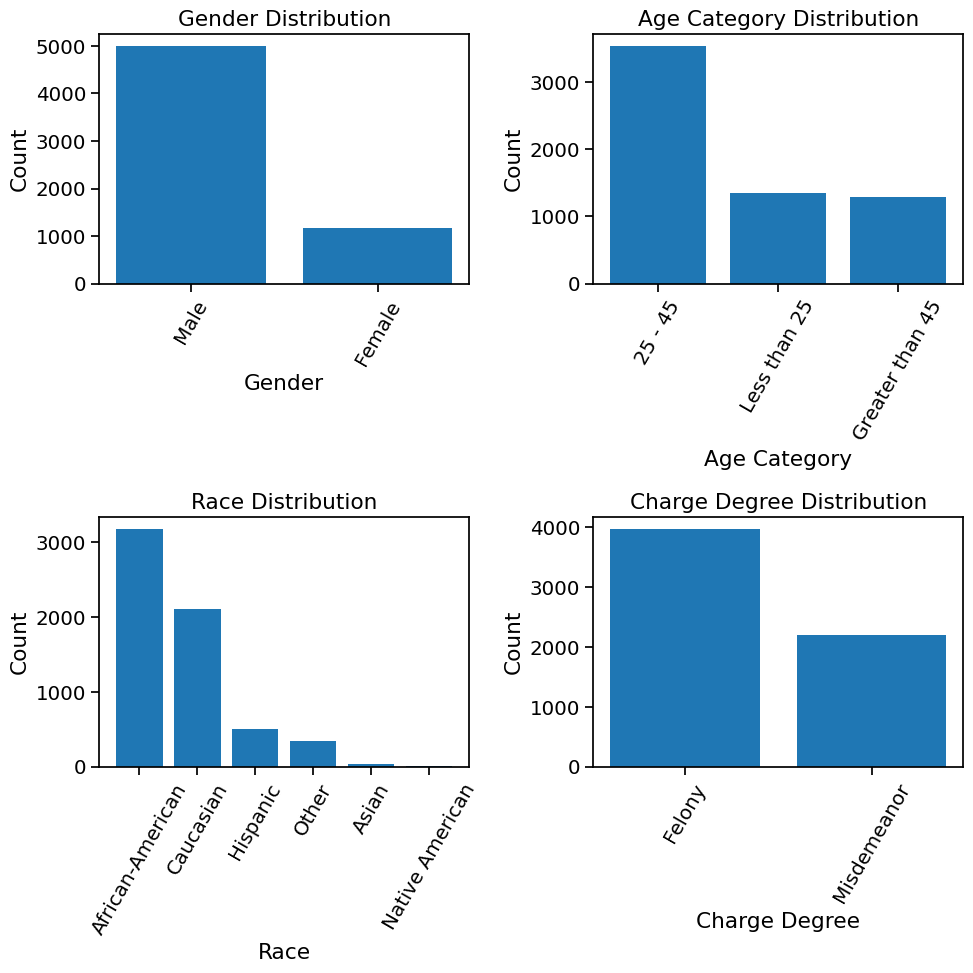

In [0]:
gender_counts = compas_df["sex"].value_counts()
print(gender_counts)
age_cat_counts = compas_df["age_cat"].value_counts()
print(age_cat_counts)
race_counts = compas_df["race"].value_counts()
print(race_counts)
charge_degree_counts = compas_df["c_charge_degree"].value_counts()
print(charge_degree_counts)

fig, axes = plt.subplots(2, 2, figsize=(10, 10))

for ax in axes.flat:
    ax.tick_params(axis='x', labelrotation=60)

axes[0,0].bar(gender_counts.index, gender_counts.values)
axes[0,0].set_title('Gender Distribution')
axes[0,0].set_xlabel('Gender')
axes[0,0].set_ylabel('Count')

axes[0,1].bar(age_cat_counts.index, age_cat_counts.values)
axes[0,1].set_title('Age Category Distribution')
axes[0,1].set_xlabel('Age Category')
axes[0,1].set_ylabel('Count')

axes[1,0].bar(race_counts.index, race_counts.values)
axes[1,0].set_title('Race Distribution')
axes[1,0].set_xlabel('Race')
axes[1,0].set_ylabel('Count')

axes[1,1].bar(charge_degree_counts.index, charge_degree_counts.values)
axes[1,1].set_title('Charge Degree Distribution')
axes[1,1].set_xlabel('Charge Degree')
axes[1,1].set_ylabel('Count')
axes[1,1].set_xticks(['F', 'M'])
axes[1,1].set_xticklabels(['Felony', 'Misdemeanor'])

plt.tight_layout()
fig.savefig("compas_cat_eda.png", dpi=300, bbox_inches="tight")
plt.show()

### Distribution of Numerical Variables

               age
count  6172.000000
mean     34.534511
std      11.730938
min      18.000000
25%      25.000000
50%      31.000000
75%      42.000000
max      96.000000


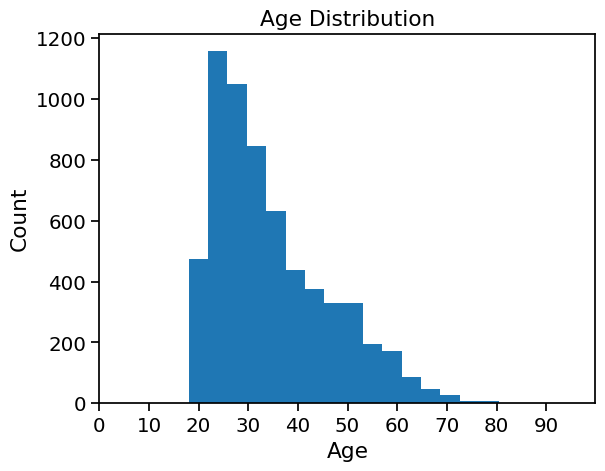

In [0]:
print(compas_df[["age"]].describe())

plt.hist(x = 'age', data = compas_df, bins = 20)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.xticks(range(0, 100, 10))
plt.savefig('compas_age_distribution.png', dpi=300, bbox_inches='tight')
plt.show()


       juv_fel_count
count    6172.000000
mean        0.059300
std         0.463599
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        20.000000


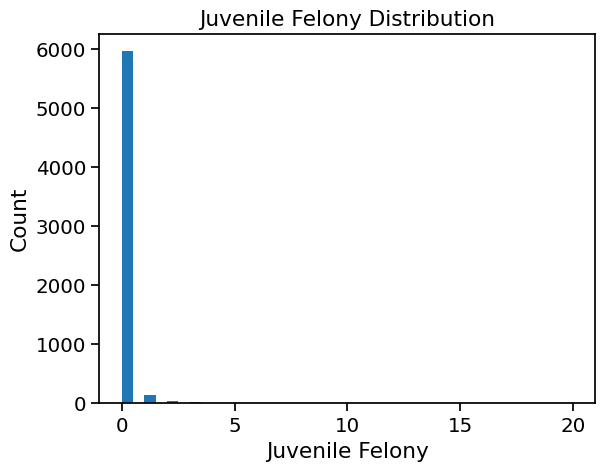

In [0]:
print(compas_df[["juv_fel_count"]].describe())

plt.hist(x = 'juv_fel_count', data = compas_df, bins = 40)
plt.title('Juvenile Felony Distribution')
plt.xlabel('Juvenile Felony')
plt.ylabel('Count')
plt.show()

       juv_misd_count
count     6172.000000
mean         0.091218
std          0.497872
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         13.000000


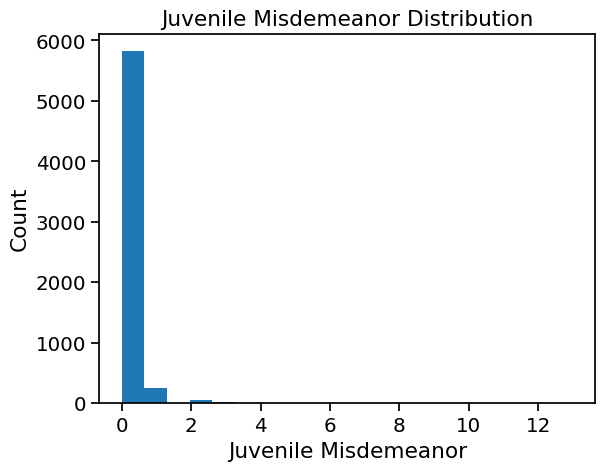

In [0]:
print(compas_df[["juv_misd_count"]].describe())

plt.hist(x = 'juv_misd_count', data = compas_df, bins = 20)
plt.title('Juvenile Misdemeanor Distribution')
plt.xlabel('Juvenile Misdemeanor')
plt.ylabel('Count')
plt.show()

       juv_other_count
count      6172.000000
mean          0.110661
std           0.470731
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           9.000000


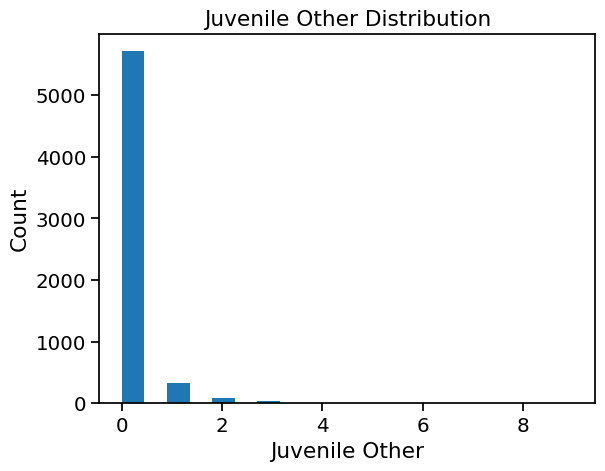

In [0]:
print(compas_df[["juv_other_count"]].describe())

plt.hist(x = 'juv_other_count', data = compas_df, bins = 20)
plt.title('Juvenile Other Distribution')
plt.xlabel('Juvenile Other')
plt.ylabel('Count')
plt.show()

       priors_count
count   6172.000000
mean       3.246436
std        4.743770
min        0.000000
25%        0.000000
50%        1.000000
75%        4.000000
max       38.000000


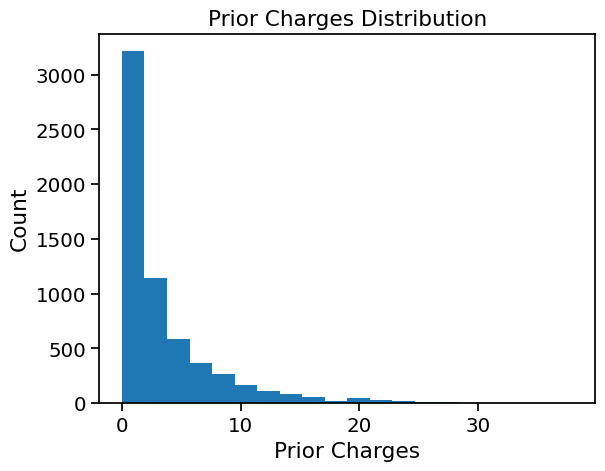

In [0]:
print(compas_df[["priors_count"]].describe())

plt.hist(x='priors_count', data=compas_df, bins = 20)
plt.title('Prior Charges Distribution')
plt.xlabel('Prior Charges')
plt.ylabel('Count')
plt.savefig('compas_prior_count_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## Keeping White and Non-white race

In [0]:
compas_df_coop = compas_df[(compas_df['race'] == 'African-American') | (compas_df['race'] == 'Caucasian')]
compas_df_coop.shape

(5278, 10)

## Modeling

In [0]:
features = [
    'age_cat',
    'priors_count',
    'juv_fel_count',
    'juv_misd_count',
    'juv_other_count',
    'sex',
    'c_charge_degree'
]

num_features = [
    'priors_count',
    'juv_fel_count',
    'juv_misd_count',
    'juv_other_count'
]

cat_features = [
    'age_cat',
    'sex',
    'c_charge_degree'
]

target = "two_year_recid"

# 4. Replicating Cooper's Ensembling to study Self-Consistency

Measured Self-consistency (SC), Accuracy and Abstention rates of individual learning algorithms (Logistic Regression) with a threshold of 0.75

### Running  Algorithm 1 - Simple Ensembling (With Logistic Regression)
Different models are produced by using different set of training points (by bootstrapping) and the models predict if the SC is high and abstain if the SC is low. 

In [0]:
logistic_regression_results = run_n_splits_experiment(
    df=compas_df_coop,
    features=features,
    target=target,
    num_features=num_features,
    cat_features=cat_features,
    model_type="Logistic Regression",
    B_ensembles=101,
    SC_threshold=0.75,
    n_splits=10
)

summary = pd.DataFrame({
    "Mean": logistic_regression_results.drop(columns=["split_seed"]).mean(numeric_only=True),
    "Std": logistic_regression_results.drop(columns=["split_seed"]).std(numeric_only=True)
})

print(summary)


---------------- LOGISTIC REGRESSION RESULTS ----------------

Average over 10 train-test splits:

abstention_rate                 0.076326
predicted_rate                  0.923674
mean_self_consistency           0.958353
ambiguity                       0.207292
non_abstain_accuracy            0.682369
non_abstain_precision           0.693395
non_abstain_recall              0.587023
non_abstain_f1                  0.634841
full_accuracy_no_abstention     0.670076
full_precision_no_abstention    0.671777
full_recall_no_abstention       0.591194
full_f1_no_abstention           0.628708
dtype: float64

Standard deviation over 10 train-test splits:

abstention_rate                 0.030954
predicted_rate                  0.030954
mean_self_consistency           0.006278
ambiguity                       0.013018
non_abstain_accuracy            0.010353
non_abstain_precision           0.028068
non_abstain_recall              0.029066
non_abstain_f1                  0.013165
full_accuracy_no_

### Running  Algorithm 2 - Super Ensembling (With Random Forest)
Here, we used bagged models. When these bagged models are trained on bootstrapped data, the bagging process in these models reduce the variance and we expect the ensemble of such bagged models to have higher SC and lower abstention rates.

In [0]:
random_forest_results = run_n_splits_experiment(
    df=compas_df_coop,
    features=features,
    target=target,
    num_features=num_features,
    cat_features=cat_features,
    model_type="Random Forest",
    B_ensembles=101,
    SC_threshold=0.75,
    n_splits=10
)

summary = pd.DataFrame({
    "Mean": random_forest_results.drop(columns=["split_seed"]).mean(numeric_only=True),
    "Std": random_forest_results.drop(columns=["split_seed"]).std(numeric_only=True)
})

print(summary)


---------------- RANDOM FOREST RESULTS ----------------

Average over 10 train-test splits:

abstention_rate                 0.213258
predicted_rate                  0.786742
mean_self_consistency           0.880411
ambiguity                       0.556061
non_abstain_accuracy            0.691659
non_abstain_precision           0.689758
non_abstain_recall              0.552703
non_abstain_f1                  0.612980
full_accuracy_no_abstention     0.662784
full_precision_no_abstention    0.667612
full_recall_no_abstention       0.571829
full_f1_no_abstention           0.615685
dtype: float64

Standard deviation over 10 train-test splits:

abstention_rate                 0.020558
predicted_rate                  0.020558
mean_self_consistency           0.006630
ambiguity                       0.029567
non_abstain_accuracy            0.016493
non_abstain_precision           0.030880
non_abstain_recall              0.027634
non_abstain_f1                  0.019950
full_accuracy_no_absten

### Running Decision Tree

In [0]:
decision_tree_results = run_n_splits_experiment(
    df=compas_df_coop,
    features=features,
    target=target,
    num_features=num_features,
    cat_features=cat_features,
    model_type="Decision Tree",
    B_ensembles=101,
    SC_threshold=0.75,
    n_splits=10
)

summary = pd.DataFrame({
    "Mean": decision_tree_results.drop(columns=["split_seed"]).mean(numeric_only=True),
    "Std": decision_tree_results.drop(columns=["split_seed"]).std(numeric_only=True)
})

print(summary)


---------------- DECISION TREE RESULTS ----------------

Average over 10 train-test splits:

abstention_rate                 0.246307
predicted_rate                  0.753693
mean_self_consistency           0.866233
ambiguity                       0.575379
non_abstain_accuracy            0.690801
non_abstain_precision           0.683445
non_abstain_recall              0.515010
non_abstain_f1                  0.586570
full_accuracy_no_abstention     0.658428
full_precision_no_abstention    0.671107
full_recall_no_abstention       0.545188
full_f1_no_abstention           0.601175
dtype: float64

Standard deviation over 10 train-test splits:

abstention_rate                 0.020016
predicted_rate                  0.020016
mean_self_consistency           0.006394
ambiguity                       0.033041
non_abstain_accuracy            0.013117
non_abstain_precision           0.032519
non_abstain_recall              0.023236
non_abstain_f1                  0.014811
full_accuracy_no_absten

## Studying Accuracy vs Self-Consistency

Plotted Accuracy vs SC, Accuracy vs Ambiguity and SC Ambiguity using the above ensembling technique for different train test splits using different Learning Algorithms  (Logistic Regression, Decision Tree, Random Forest, Gradient Boosting)

- 100 train-test splits to produce ensembles
- Each ensemble consisting of 20 models trained by bootstrapping training data

### Using Logistic Regression (100 train-test splits with ensemble size 20)

In [0]:
logistic_regression_100split_results = run_n_splits_experiment(
    df=compas_df_coop,
    features=features,
    target=target,
    num_features=num_features,
    cat_features=cat_features,
    model_type="Logistic Regression",
    B_ensembles=20,
    SC_threshold=0.75,
    n_splits=100
)

summary = pd.DataFrame({
    "Mean": logistic_regression_100split_results.drop(columns=["split_seed"]).mean(numeric_only=True),
    "Std": logistic_regression_100split_results.drop(columns=["split_seed"]).std(numeric_only=True)
})

print(summary)


---------------- LOGISTIC REGRESSION RESULTS ----------------

Average over 100 train-test splits:

abstention_rate                 0.079186
predicted_rate                  0.920814
mean_self_consistency           0.960086
ambiguity                       0.148542
non_abstain_accuracy            0.677990
non_abstain_precision           0.684325
non_abstain_recall              0.582593
non_abstain_f1                  0.628517
full_accuracy_no_abstention     0.664564
full_precision_no_abstention    0.665227
full_recall_no_abstention       0.579876
full_f1_no_abstention           0.619198
dtype: float64

Standard deviation over 100 train-test splits:

abstention_rate                 0.025188
predicted_rate                  0.025188
mean_self_consistency           0.007456
ambiguity                       0.026497
non_abstain_accuracy            0.015096
non_abstain_precision           0.028945
non_abstain_recall              0.028755
non_abstain_f1                  0.017427
full_accuracy_n

### Using Random Forest (100 train-test splits with ensemble size 20)

In [0]:
random_forest_100split_results = run_n_splits_experiment(
    df=compas_df_coop,
    features=features,
    target=target,
    num_features=num_features,
    cat_features=cat_features,
    model_type="Random Forest",
    B_ensembles=20,
    SC_threshold=0.75,
    n_splits=100
)

summary = pd.DataFrame({
    "Mean": random_forest_100split_results.drop(columns=["split_seed"]).mean(numeric_only=True),
    "Std": random_forest_100split_results.drop(columns=["split_seed"]).std(numeric_only=True)
})

print(summary)


---------------- RANDOM FOREST RESULTS ----------------

Average over 100 train-test splits:

abstention_rate                 0.233295
predicted_rate                  0.766705
mean_self_consistency           0.881389
ambiguity                       0.401979
non_abstain_accuracy            0.689904
non_abstain_precision           0.685192
non_abstain_recall              0.542649
non_abstain_f1                  0.604919
full_accuracy_no_abstention     0.659754
full_precision_no_abstention    0.664037
full_recall_no_abstention       0.562333
full_f1_no_abstention           0.608485
dtype: float64

Standard deviation over 100 train-test splits:

abstention_rate                 0.032407
predicted_rate                  0.032407
mean_self_consistency           0.011620
ambiguity                       0.045700
non_abstain_accuracy            0.013671
non_abstain_precision           0.024176
non_abstain_recall              0.030174
non_abstain_f1                  0.020019
full_accuracy_no_abst

### Using Decision Tree (100 train-test splits with ensemble size 20)

In [0]:
decision_tree_100split_results = run_n_splits_experiment(
    df=compas_df_coop,
    features=features,
    target=target,
    num_features=num_features,
    cat_features=cat_features,
    model_type="Decision Tree",
    B_ensembles=20,
    SC_threshold=0.75,
    n_splits=100
)

summary = pd.DataFrame({
    "Mean": decision_tree_100split_results.drop(columns=["split_seed"]).mean(numeric_only=True),
    "Std": decision_tree_100split_results.drop(columns=["split_seed"]).std(numeric_only=True)
})

print(summary)


---------------- DECISION TREE RESULTS ----------------

Average over 100 train-test splits:

abstention_rate                 0.266515
predicted_rate                  0.733485
mean_self_consistency           0.867288
ambiguity                       0.433759
non_abstain_accuracy            0.685948
non_abstain_precision           0.675142
non_abstain_recall              0.494232
non_abstain_f1                  0.569787
full_accuracy_no_abstention     0.653977
full_precision_no_abstention    0.665798
full_recall_no_abstention       0.533196
full_f1_no_abstention           0.591619
dtype: float64

Standard deviation over 100 train-test splits:

abstention_rate                 0.033345
predicted_rate                  0.033345
mean_self_consistency           0.011572
ambiguity                       0.042571
non_abstain_accuracy            0.014461
non_abstain_precision           0.027987
non_abstain_recall              0.032007
non_abstain_f1                  0.022643
full_accuracy_no_abst

### Using Gradient Boosting (100 train-test splits with ensemble size 20)

In [0]:
gb_100split_results = run_n_splits_experiment(
    df=compas_df_coop,
    features=features,
    target=target,
    num_features=num_features,
    cat_features=cat_features,
    model_type="Gradient Boosting",
    B_ensembles=20,
    SC_threshold=0.75,
    n_splits=100
)

summary = pd.DataFrame({
    "Mean": gb_100split_results.drop(columns=["split_seed"]).mean(numeric_only=True),
    "Std": gb_100split_results.drop(columns=["split_seed"]).std(numeric_only=True)
})

print(summary)


---------------- GRADIENT BOOSTING RESULTS ----------------

Average over 100 train-test splits:

abstention_rate                 0.112623
predicted_rate                  0.887377
mean_self_consistency           0.939767
ambiguity                       0.238722
non_abstain_accuracy            0.685120
non_abstain_precision           0.682374
non_abstain_recall              0.595947
non_abstain_f1                  0.635685
full_accuracy_no_abstention     0.673456
full_precision_no_abstention    0.669620
full_recall_no_abstention       0.605166
full_f1_no_abstention           0.635508
dtype: float64

Standard deviation over 100 train-test splits:

abstention_rate                 0.028469
predicted_rate                  0.028469
mean_self_consistency           0.010057
ambiguity                       0.032436
non_abstain_accuracy            0.013775
non_abstain_precision           0.021441
non_abstain_recall              0.028566
non_abstain_f1                  0.018331
full_accuracy_no_

### Plotting Accuracy vs SC for all model types

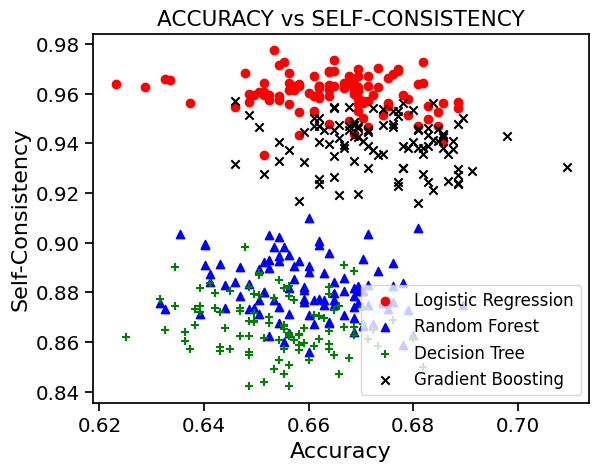

In [0]:
plt.scatter(logistic_regression_100split_results['full_accuracy_no_abstention'], logistic_regression_100split_results['mean_self_consistency'], color = "red", label = "Logistic Regression", marker = "o")
plt.scatter(random_forest_100split_results['full_accuracy_no_abstention'], random_forest_100split_results['mean_self_consistency'], color = "blue", label = "Random Forest", marker = "^")
plt.scatter(decision_tree_100split_results['full_accuracy_no_abstention'], decision_tree_100split_results['mean_self_consistency'], color = "green", label = "Decision Tree", marker = "+")
plt.scatter(gb_100split_results['full_accuracy_no_abstention'], gb_100split_results['mean_self_consistency'], color = "black", label = "Gradient Boosting", marker = "x")
plt.xlabel("Accuracy", fontsize = 16)
plt.ylabel("Self-Consistency", fontsize = 16)
plt.title("ACCURACY vs SELF-CONSISTENCY")

plt.legend(fontsize = 12, loc = 'lower right')
plt.savefig("acc_sc_compas.png", dpi=300, bbox_inches="tight")
plt.show()

### Plotting Accuracy vs Ambiguity for all model types

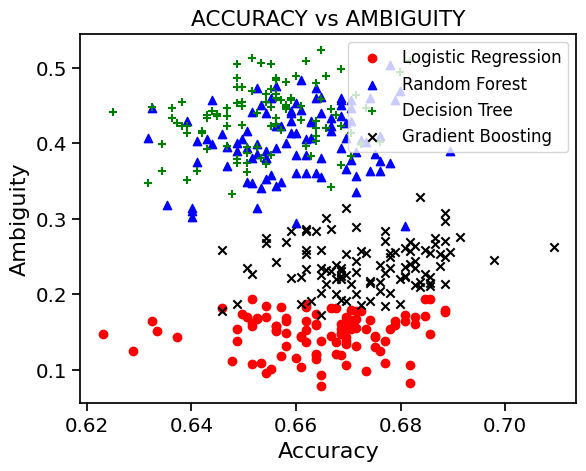

In [0]:
plt.scatter(logistic_regression_100split_results['full_accuracy_no_abstention'], logistic_regression_100split_results['ambiguity'], color = "red", label = "Logistic Regression", marker = "o")
plt.scatter(random_forest_100split_results['full_accuracy_no_abstention'], random_forest_100split_results['ambiguity'], color = "blue", label = "Random Forest", marker = "^")
plt.scatter(decision_tree_100split_results['full_accuracy_no_abstention'], decision_tree_100split_results['ambiguity'], color = "green", label = "Decision Tree", marker = "+")
plt.scatter(gb_100split_results['full_accuracy_no_abstention'], gb_100split_results['ambiguity'], color = "black", label = "Gradient Boosting", marker = "x")
plt.xlabel("Accuracy", fontsize = 16)
plt.ylabel("Ambiguity", fontsize = 16)
plt.title("ACCURACY vs AMBIGUITY")

plt.legend(fontsize = 12, loc = 'upper right')
plt.savefig("acc_amb_compas.png", dpi=300, bbox_inches="tight")
plt.show()

### Plotting Self-Consistency vs Ambiguity for all model types

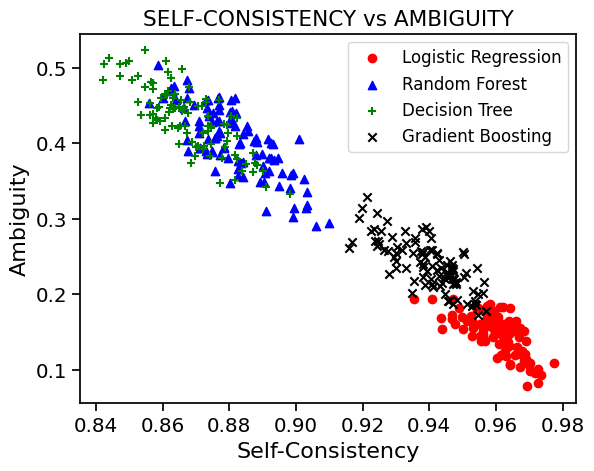

In [0]:
plt.scatter(logistic_regression_100split_results['mean_self_consistency'], logistic_regression_100split_results['ambiguity'], color = "red", label = "Logistic Regression", marker = "o")
plt.scatter(random_forest_100split_results['mean_self_consistency'], random_forest_100split_results['ambiguity'], color = "blue", label = "Random Forest", marker = "^")
plt.scatter(decision_tree_100split_results['mean_self_consistency'], decision_tree_100split_results['ambiguity'], color = "green", label = "Decision Tree", marker = "+")
plt.scatter(gb_100split_results['mean_self_consistency'], gb_100split_results['ambiguity'], color = "black", label = "Gradient Boosting", marker = "x")
plt.xlabel("Self-Consistency", fontsize = 16)
plt.ylabel("Ambiguity", fontsize = 16)
plt.title("SELF-CONSISTENCY vs AMBIGUITY")

plt.legend(fontsize = 12, loc = 'upper right')
plt.savefig("sc_amb_compas.png", dpi=300, bbox_inches="tight")
plt.show()

# 5. Selective Ensembling

Constructed ensembles of individual learners (Logistic Regression, Decision Tree, Random Forest, Gradient Boosting) by bootstrapping and used majority vote for final prediction.  

Measured Self-consistency (SC), Accuracy and Abstention rates of these ensembles with a threshold of 0.75

- Number of Ensembles (E) = 10
- Number of models in each Ensemble (B) = 11

In [0]:
models_set = ["Logistic Regression", "Random Forest", "Decision Tree", "Gradient Boosting"]

for model in models_set:
    ensemble_agreement(
        df=compas_df_coop,
        features=features,
        target=target,
        num_features=num_features,
        cat_features=cat_features,
        model_type=model,
        ensemble_size=11,
        SC_threshold=0.75,
        n_ensembles=10
    )


---------------- LOGISTIC REGRESSION RESULTS ----------------

model_type                      Logistic Regression
abstention_rate                            0.017992
predicted_rate                             0.982008
mean_self_consistency                      0.989857
ambiguity                                  0.086174
non_abstain_accuracy                       0.671167
non_abstain_precision                      0.636986
non_abstain_recall                         0.605206
non_abstain_f1                              0.62069
full_accuracy_no_abstention                0.667614
full_precision_no_abstention               0.632159
full_recall_no_abstention                  0.609342
full_f1_no_abstention                      0.620541
Name: 0, dtype: object

---------------- RANDOM FOREST RESULTS ----------------

model_type                      Random Forest
abstention_rate                      0.033144
predicted_rate                       0.966856
mean_self_consistency                 0.9

Running the Selective Ensembling experiment across 10 different train-test splits

In [0]:
models_set = ["Logistic Regression", "Random Forest", "Decision Tree", "Gradient Boosting"]

for model in models_set:
    print(f"\n---------------- {model.upper()} RESULTS ----------------\n")
    selective_ensembling_split_results = ensemble_agreement_n_splits(
            df=compas_df_coop,
            features=features,
            target=target,
            num_features=num_features,
            cat_features=cat_features,
            model_type=model,
            ensemble_size=11,
            SC_threshold=0.75,
            n_ensembles=10,
            splits = 10
        )
    
    summary = pd.DataFrame({
        "Mean": selective_ensembling_split_results.mean(numeric_only=True),
        "Std": selective_ensembling_split_results.std(numeric_only=True)
    })

    print(summary)


---------------- LOGISTIC REGRESSION RESULTS ----------------

                                  Mean       Std
abstention_rate               0.005966  0.004952
predicted_rate                0.994034  0.004952
mean_self_consistency         0.996673  0.002775
ambiguity                     0.126610  0.026186
non_abstain_accuracy          0.671530  0.009272
non_abstain_precision         0.674074  0.018981
non_abstain_recall            0.592328  0.019200
non_abstain_f1                0.630283  0.013269
full_accuracy_no_abstention   0.669981  0.009783
full_precision_no_abstention  0.671314  0.020638
full_recall_no_abstention     0.592704  0.019977
full_f1_no_abstention         0.629224  0.013383

---------------- RANDOM FOREST RESULTS ----------------

                                  Mean       Std
abstention_rate               0.049053  0.015546
predicted_rate                0.950947  0.015546
mean_self_consistency         0.973969  0.006387
ambiguity                     0.330492  0.016

### Visualization for comparing Cooper's Ensembling with Selective Ensembling

In [0]:
cooper_df = run_n_splits_experiment(
    df=compas_df_coop, features=features, target=target,
    num_features=num_features, cat_features=cat_features,
    model_type="Logistic Regression", 
    B_ensembles=11, SC_threshold=0.75, n_splits=10
)
cooper_df["split"] = range(1, 11)
cooper_df["method"] = "Cooper's Ensemble"

selective_df = ensemble_agreement_n_splits(
    df=compas_df_coop, features=features, target=target,
    num_features=num_features, cat_features=cat_features,
    model_type="Logistic Regression",
    ensemble_size=11, SC_threshold=0.75, n_ensembles=10, splits=10
)
selective_df["split"] = range(1, 11)
selective_df["method"] = "Selective Ensembling"

combined_comparison_df = pd.concat([cooper_df, selective_df], ignore_index=True)


---------------- LOGISTIC REGRESSION RESULTS ----------------

Average over 10 train-test splits:

abstention_rate                 0.070170
predicted_rate                  0.929830
mean_self_consistency           0.959721
ambiguity                       0.131439
non_abstain_accuracy            0.680690
non_abstain_precision           0.685011
non_abstain_recall              0.594766
non_abstain_f1                  0.636285
full_accuracy_no_abstention     0.671117
full_precision_no_abstention    0.673645
full_recall_no_abstention       0.591008
full_f1_no_abstention           0.629350
dtype: float64

Standard deviation over 10 train-test splits:

abstention_rate                 0.021601
predicted_rate                  0.021601
mean_self_consistency           0.007067
ambiguity                       0.030969
non_abstain_accuracy            0.011212
non_abstain_precision           0.024010
non_abstain_recall              0.019758
non_abstain_f1                  0.013090
full_accuracy_no_

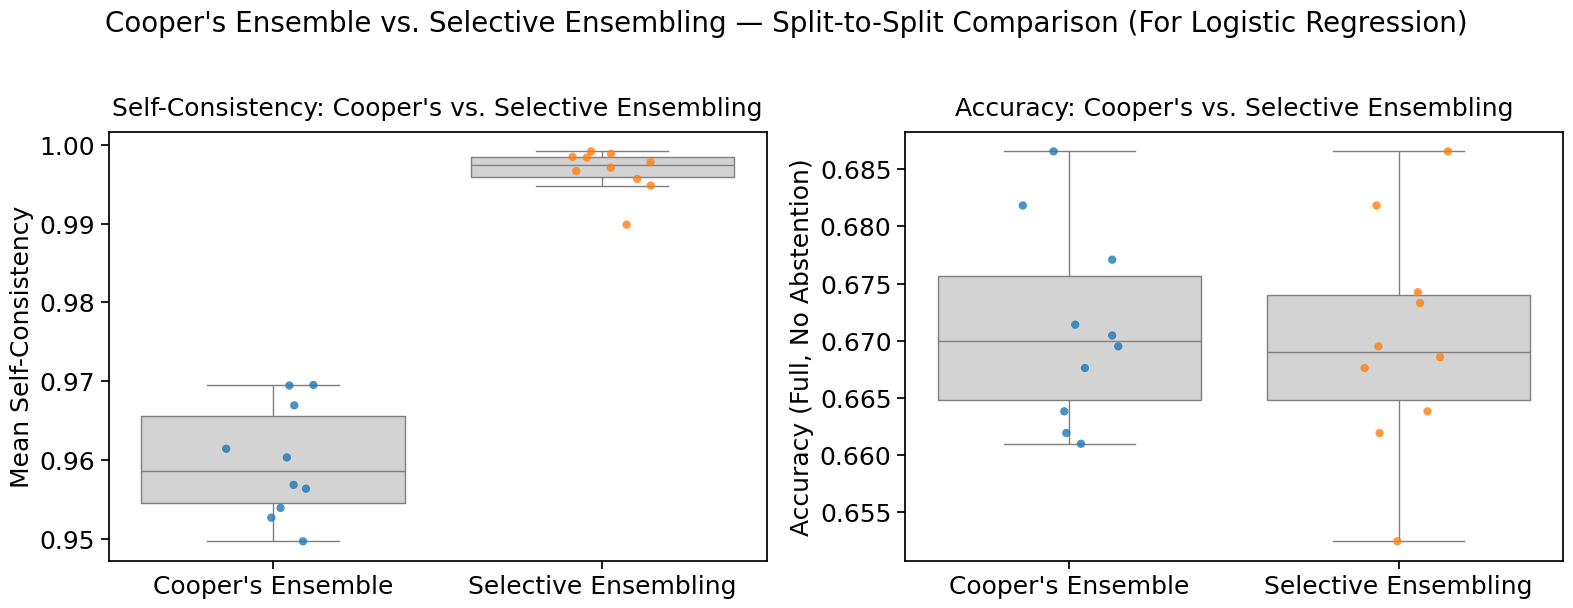

In [0]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Self-consistency ---
sns.boxplot(
    data=combined_comparison_df,
    x="method",
    y="mean_self_consistency",
    ax=axes[0],
    color="lightgray",
    fliersize=0
)
sns.stripplot(
    data=combined_comparison_df,
    x="method",
    y="mean_self_consistency",
    ax=axes[0],
    hue="method",
    size=6,
    jitter=0.15,
    alpha=0.8,
    legend=False
)

axes[0].set_xlabel("", fontsize=18)
axes[0].set_ylabel("Mean Self-Consistency", fontsize=18)
axes[0].set_title(
    "Self-Consistency: Cooper's vs. Selective Ensembling",
    fontsize=18,
    pad=12
)
axes[0].tick_params(axis="both", labelsize=18)


# --- Accuracy ---
sns.boxplot(
    data=combined_comparison_df,
    x="method",
    y="full_accuracy_no_abstention",
    ax=axes[1],
    color="lightgray",
    fliersize=0
)
sns.stripplot(
    data=combined_comparison_df,
    x="method",
    y="full_accuracy_no_abstention",
    ax=axes[1],
    hue="method",
    size=6,
    jitter=0.15,
    alpha=0.8,
    legend=False
)

axes[1].set_xlabel("", fontsize=18)
axes[1].set_ylabel("Accuracy (Full, No Abstention)", fontsize=18)
axes[1].set_title(
    "Accuracy: Cooper's vs. Selective Ensembling",
    fontsize=18,
    pad=12
)
axes[1].tick_params(axis="both", labelsize=18)


# Overall title
fig.suptitle(
    "Cooper's Ensemble vs. Selective Ensembling — Split-to-Split Comparison (For Logistic Regression)",
    fontsize=20,
    y=1.02
)

fig.tight_layout()

fig.savefig(
    "compas_simple_vs_selective_ensemble.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [0]:
cooper_df_rf = run_n_splits_experiment(
    df=compas_df_coop, features=features, target=target,
    num_features=num_features, cat_features=cat_features,
    model_type="Random Forest",
    B_ensembles=11, SC_threshold=0.75, n_splits=10
)
cooper_df_rf["split"] = range(1, 11)
cooper_df_rf["method"] = "Cooper's Ensemble"

selective_df_rf = ensemble_agreement_n_splits(
    df=compas_df_coop, features=features, target=target,
    num_features=num_features, cat_features=cat_features,
    model_type="Random Forest",
    ensemble_size=11, SC_threshold=0.75, n_ensembles=10, splits=10
)
selective_df_rf["split"] = range(1, 11)
selective_df_rf["method"] = "Selective Ensembling"

combined_comparison_df_rf = pd.concat([cooper_df_rf, selective_df_rf], ignore_index=True)


---------------- RANDOM FOREST RESULTS ----------------

Average over 10 train-test splits:

abstention_rate                 0.218466
predicted_rate                  0.781534
mean_self_consistency           0.878337
ambiguity                       0.353598
non_abstain_accuracy            0.690934
non_abstain_precision           0.691077
non_abstain_recall              0.545802
non_abstain_f1                  0.609360
full_accuracy_no_abstention     0.661648
full_precision_no_abstention    0.669776
full_recall_no_abstention       0.561741
full_f1_no_abstention           0.610617
dtype: float64

Standard deviation over 10 train-test splits:

abstention_rate                 0.015426
predicted_rate                  0.015426
mean_self_consistency           0.005761
ambiguity                       0.019024
non_abstain_accuracy            0.017167
non_abstain_precision           0.031932
non_abstain_recall              0.026591
non_abstain_f1                  0.021897
full_accuracy_no_absten

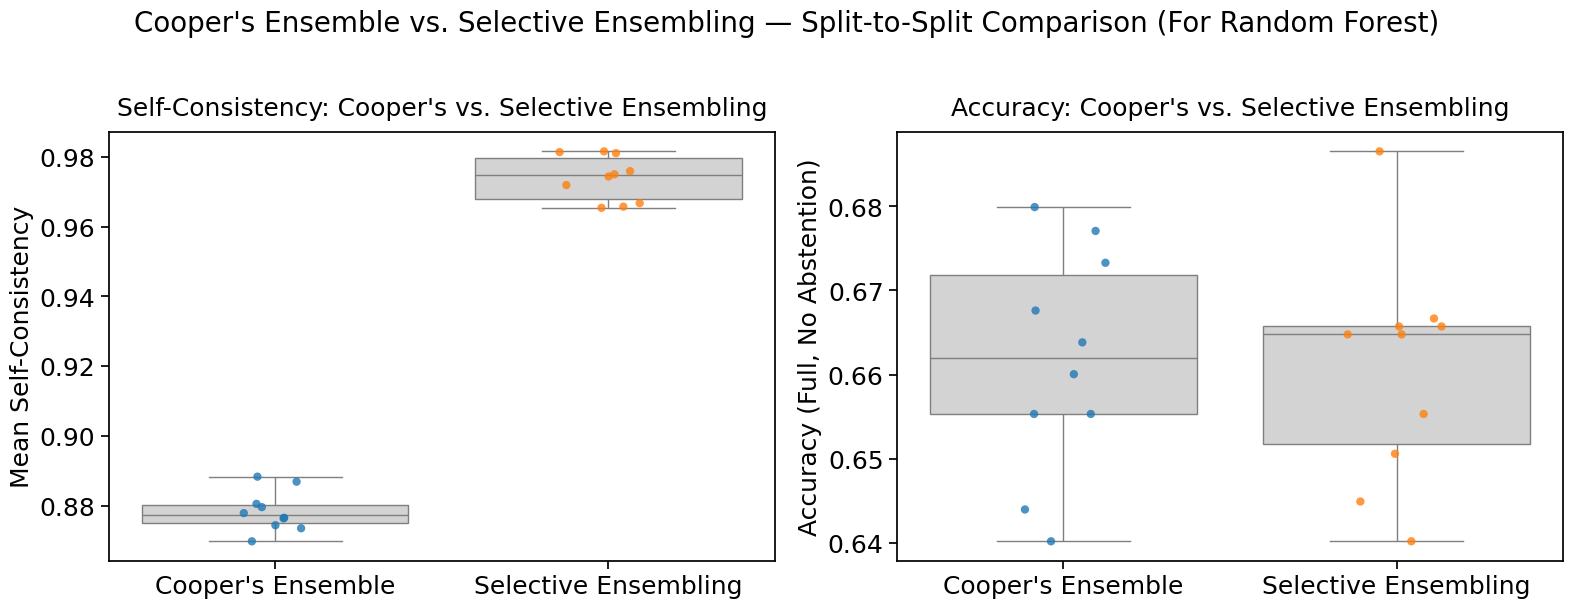

In [0]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Self-consistency ---
sns.boxplot(
    data=combined_comparison_df_rf,
    x="method",
    y="mean_self_consistency",
    ax=axes[0],
    color="lightgray",
    fliersize=0
)
sns.stripplot(
    data=combined_comparison_df_rf,
    x="method",
    y="mean_self_consistency",
    ax=axes[0],
    hue="method",
    size=6,
    jitter=0.15,
    alpha=0.8,
    legend=False
)

axes[0].set_xlabel("", fontsize=18)
axes[0].set_ylabel("Mean Self-Consistency", fontsize=18)
axes[0].set_title(
    "Self-Consistency: Cooper's vs. Selective Ensembling",
    fontsize=18,
    pad=12
)
axes[0].tick_params(axis="both", labelsize=18)


# --- Accuracy ---
sns.boxplot(
    data=combined_comparison_df_rf,
    x="method",
    y="full_accuracy_no_abstention",
    ax=axes[1],
    color="lightgray",
    fliersize=0
)
sns.stripplot(
    data=combined_comparison_df_rf,
    x="method",
    y="full_accuracy_no_abstention",
    ax=axes[1],
    hue="method",
    size=6,
    jitter=0.15,
    alpha=0.8,
    legend=False
)

axes[1].set_xlabel("", fontsize=18)
axes[1].set_ylabel("Accuracy (Full, No Abstention)", fontsize=18)
axes[1].set_title(
    "Accuracy: Cooper's vs. Selective Ensembling",
    fontsize=18,
    pad=12
)
axes[1].tick_params(axis="both", labelsize=18)


# Overall title
fig.suptitle(
    "Cooper's Ensemble vs. Selective Ensembling — Split-to-Split Comparison (For Random Forest)",
    fontsize=20,
    y=1.02
)

fig.tight_layout()

fig.savefig(
    "compas_simple_vs_selective_ensemble_random_forest.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 6. Super Learner Ensembling

Constructed Super Learner using 4 different learning algorithms (Logistic Regression, Decision Tree, Random Forest, Gradient Boosting) and used Logistic Regression as the Meta Learner which combines predictions of individual learners to give final predictions.  

Measured the SC and Accuracy of Super Learner and the individual learners by bootstrapping the training data to obtain different training sets

- 20 Super Learners are constructed by bootstrapping the training data
- 10-fold CV is used to construct the Super Learner

In [0]:
def weighted_log_loss_objective(weights, Z_stack, y_val):
    weights = softmax(weights)
    combined = Z_stack @ weights
    # Clipping values to tackle infinity cases in log loss function
    combined = np.clip(combined, 1e-7, 1 - 1e-7)
    return log_loss(y_val, combined)

In [0]:
class WeightedLogLossSuperLearner:
    def __init__(self, models_count, optimizer = "Powell", threshold = 0.5):
        self.models_count = models_count
        self.final_weights = np.empty(self.models_count)
        self.threshold = threshold
        self.optimizer = optimizer
        self.optimizer_result = False

    def fit(self, Z_stack, y):
        if Z_stack.shape[1] != self.models_count:
            raise Exception("Model Count does not match the columns in Base Learner Predictions")

        x0 = np.zeros(self.models_count)  

        result = minimize(
            weighted_log_loss_objective,
            x0 = x0,
            args = (Z_stack, y),
            method = self.optimizer
        )

        self.final_weights = softmax(result.x)
        self.optimizer_result = result.success
        return self

    def predict_proba(self, Z_stack):
        return Z_stack @ self.final_weights

    def predict(self, Z_stack):
        pred_probs = Z_stack @ self.final_weights
        return np.where(pred_probs >= self.threshold, 1, 0)

In [0]:
def ClassicalSuperLearnerEnsembleAgreement(df, features, target, num_features, cat_features, model_types, n_splits = 10, cv_folds = 10, do_bootstrap = False, random_state = 1):
    results = []
    split_predictions = []
    M = len(model_types)
    base_predictions = {model_type: [] for model_type in model_types}

    X_train, X_test, y_train, y_test = train_test_split(
                df[features],
                df[target],
                test_size = 0.2,
                random_state = random_state
            )
    
    X_train_processed, X_test_processed = preprocess_split(
            X_train,
            X_test,
            num_features,
            cat_features
        )

    for split_seed in range(1, n_splits+1):
        split_result = {}
        
        meta_Z, meta_y = list(), list()        

        X_train_split = X_train_processed.copy()
        y_train_split = y_train.copy()

        if do_bootstrap:
            X_train_split, y_train_split = resample(
                X_train_split,
                y_train_split,
                replace=True,
                random_state = split_seed
            )

        kfold = KFold(n_splits=cv_folds, random_state=split_seed, shuffle=True)

        for train_ix, test_ix in kfold.split(X_train_split):
            fold_yhats = list()
            train_X, test_X = X_train_split[train_ix], X_train_split[test_ix]
            train_y = y_train_split.iloc[train_ix]
            test_y = y_train_split.iloc[test_ix]
            meta_y.extend(test_y)
            for model_type in model_types:
                model = get_model(model_type = model_type, random_state = 1)
                model.fit(train_X, train_y)
                yhat = model.predict(test_X)
                fold_yhats.append(yhat)
            meta_Z.append(np.column_stack(fold_yhats))
    
        sl_Z = np.vstack(meta_Z)
        sl_y = np.asarray(meta_y)

        meta_model = WeightedLogLossSuperLearner(models_count = M)
        meta_model.fit(sl_Z, sl_y)
        
        base_models = list()
        for model_type in model_types:
            base_model = get_model(model_type = model_type, random_state = 1)
            base_model.fit(X_train_split, y_train_split)
            base_models.append(base_model)                       
            yhat = base_model.predict(X_test_processed)
            split_result[f"{model_type} accuracy"] = accuracy_score(y_test, yhat)
            base_predictions[model_type].append(yhat)

        meta_Z_test = list()
        for model in base_models:
            yhat = model.predict(X_test_processed)
            meta_Z_test.append(yhat)
        meta_Z_test = np.column_stack(meta_Z_test)
        yhat = meta_model.predict(meta_Z_test)
        split_result[f"Meta Model accuracy"] = accuracy_score(y_test, yhat)

        for i, model_type in enumerate(model_types):
            split_result[f"{model_type} (w)"] = meta_model.final_weights[i]
        
        split_predictions.append(yhat)
        results.append(split_result)
    
    split_predictions = np.array(split_predictions)
    sc_scores = []
    for i in range(X_test_processed.shape[0]):
        preds_for_point = split_predictions[:,i]
        sc = self_consistency(preds_for_point)
        sc_scores.append(sc)
    mean_sc = np.mean(sc_scores)

    results_df = pd.DataFrame(results)
    display(results_df)
    #print(f"Mean Self Consistency (Pooled): {mean_sc}")
    results_df[f"Meta Learner SC"] = mean_sc

    if do_bootstrap:
        #print("------ Individual Learner Results (for Bootstrapped training data) ------")
        for model_type in model_types:
            predictions = np.asarray(base_predictions[model_type])
            sc_scores = []
            for i in range(X_test_processed.shape[0]):
                preds_for_point = predictions[:,i]
                sc = self_consistency(preds_for_point)
                #pred_results_for_point = aggregate_with_abstention(preds_for_point, SC_threshold)
                #sc = pred_results_for_point['self_consistency']
                sc_scores.append(sc)
            mean_sc = np.mean(sc_scores)
            #print(f"Mean Self Consistency ({model_type}): {mean_sc}")
            results_df[f"{model_type} SC"] = mean_sc

    return results_df

In [0]:
#Trial
models_set = ["Logistic Regression", "Random Forest", "Decision Tree", "Gradient Boosting"]

all_classical_results = []
for split in range(10):
    df_split = ClassicalSuperLearnerEnsembleAgreement(
        df=compas_df_coop, features=features, target=target,
        num_features=num_features, cat_features=cat_features,
        model_types=models_set, n_splits=5, cv_folds=10,
        do_bootstrap=True, random_state=split+1
    )
    df_split["outer_split"] = split + 1
    all_classical_results.append(df_split)
combined_classical_df = pd.concat(all_classical_results, ignore_index=True)

Logistic Regression accuracy,Random Forest accuracy,Decision Tree accuracy,Gradient Boosting accuracy,Meta Model accuracy,Logistic Regression (w),Random Forest (w),Decision Tree (w),Gradient Boosting (w)
0.6799242424242424,0.6486742424242424,0.6392045454545454,0.6571969696969697,0.6477272727272727,0.2890163889827783,0.3097914864182229,0.21568982619036342,0.18550229840863536
0.665719696969697,0.6231060606060606,0.6117424242424242,0.6581439393939394,0.6496212121212122,0.2547723703998839,0.2032474567994423,0.22176912268152332,0.3202110501191504
0.6638257575757576,0.6392045454545454,0.6316287878787878,0.6600378787878788,0.6600378787878788,0.3436609183701205,0.19194749147380122,0.20209057562836824,0.26230101452771004
0.6647727272727273,0.6486742424242424,0.6448863636363636,0.6590909090909091,0.6638257575757576,0.33153310441144646,0.15672247240864629,0.30093777289839924,0.21080665028150805
0.6666666666666666,0.6505681818181818,0.6429924242424242,0.6666666666666666,0.6714015151515151,0.35962721549225674,0.20896221616659647,0.2248654585673363,0.2065451097738104


Logistic Regression accuracy,Random Forest accuracy,Decision Tree accuracy,Gradient Boosting accuracy,Meta Model accuracy,Logistic Regression (w),Random Forest (w),Decision Tree (w),Gradient Boosting (w)
0.6666666666666666,0.6609848484848485,0.6486742424242424,0.6751893939393939,0.6638257575757576,0.3753575024223509,0.29612768166465225,0.22500534363009556,0.10350947228290139
0.6695075757575758,0.6505681818181818,0.6534090909090909,0.6704545454545454,0.6799242424242424,0.39184231006826914,0.15987489219768206,0.24723166251445314,0.2010511352195957
0.6609848484848485,0.6666666666666666,0.6619318181818182,0.6846590909090909,0.6818181818181818,0.361997573962377,0.13268655095412957,0.3119889915211561,0.19332688356233738
0.6714015151515151,0.6638257575757576,0.6515151515151515,0.6695075757575758,0.6732954545454546,0.34305395343350137,0.14058054269438455,0.23432528631484228,0.2820402175572718
0.6581439393939394,0.6723484848484849,0.6553030303030303,0.6761363636363636,0.678030303030303,0.3702749226974842,0.22501758428499055,0.19884179693242796,0.20586569608509733


Logistic Regression accuracy,Random Forest accuracy,Decision Tree accuracy,Gradient Boosting accuracy,Meta Model accuracy,Logistic Regression (w),Random Forest (w),Decision Tree (w),Gradient Boosting (w)
0.6704545454545454,0.6723484848484849,0.6676136363636364,0.6893939393939394,0.6818181818181818,0.34787923403921645,0.20304641102211624,0.2351459539803217,0.21392840095834562
0.6723484848484849,0.6647727272727273,0.6600378787878788,0.6638257575757576,0.6638257575757576,0.3063511780783818,0.3086238460846296,0.1703020852146909,0.21472289062229777
0.6571969696969697,0.6685606060606061,0.6373106060606061,0.6543560606060606,0.6543560606060606,0.3121945577077712,0.2896810070973225,0.19196170030612006,0.20616273488878625
0.6714015151515151,0.6524621212121212,0.6458333333333334,0.665719696969697,0.6704545454545454,0.320479978591772,0.21217114108086807,0.27180834301910817,0.19554053730825174
0.6628787878787878,0.6647727272727273,0.6571969696969697,0.6732954545454546,0.6704545454545454,0.3218820078495648,0.2108350262689299,0.24369006822517772,0.22359289765632753


Logistic Regression accuracy,Random Forest accuracy,Decision Tree accuracy,Gradient Boosting accuracy,Meta Model accuracy,Logistic Regression (w),Random Forest (w),Decision Tree (w),Gradient Boosting (w)
0.6590909090909091,0.6392045454545454,0.6354166666666666,0.6619318181818182,0.6534090909090909,0.3492745058730205,0.15454204440516042,0.2894784886957678,0.20670496102605126
0.6534090909090909,0.6448863636363636,0.634469696969697,0.6695075757575758,0.6590909090909091,0.32731662090323893,0.20535988293160393,0.2651234647556236,0.20220003140953352
0.6619318181818182,0.6439393939393939,0.6363636363636364,0.6628787878787878,0.6666666666666666,0.34366881246082615,0.2431749197378718,0.2427119778658932,0.17044428993540878
0.6676136363636364,0.6278409090909091,0.6240530303030303,0.6638257575757576,0.6609848484848485,0.32041022640209665,0.16930370669695213,0.3051204912462246,0.20516557565472657
0.6553030303030303,0.6335227272727273,0.6392045454545454,0.665719696969697,0.6571969696969697,0.37160337011287714,0.24499331093042825,0.17427806256415043,0.20912525639254412


Logistic Regression accuracy,Random Forest accuracy,Decision Tree accuracy,Gradient Boosting accuracy,Meta Model accuracy,Logistic Regression (w),Random Forest (w),Decision Tree (w),Gradient Boosting (w)
0.665719696969697,0.6410984848484849,0.6420454545454546,0.6543560606060606,0.6571969696969697,0.35100251724394915,0.20670820379270793,0.24436871305409683,0.19792056590924603
0.6581439393939394,0.6392045454545454,0.6363636363636364,0.665719696969697,0.6695075757575758,0.3483895279617221,0.2627158106484057,0.20231149139031507,0.18658316999955726
0.6628787878787878,0.6429924242424242,0.6354166666666666,0.6590909090909091,0.6571969696969697,0.2716232449473008,0.22735527026780153,0.2344084933278615,0.26661299145703615
0.6609848484848485,0.6439393939393939,0.6335227272727273,0.665719696969697,0.6581439393939394,0.311707145009046,0.15782860385329261,0.24623037541769624,0.2842338757199651
0.6638257575757576,0.6392045454545454,0.6382575757575758,0.6628787878787878,0.6619318181818182,0.30529630093420884,0.14004168099201028,0.29120065928743905,0.26346135878634197


Logistic Regression accuracy,Random Forest accuracy,Decision Tree accuracy,Gradient Boosting accuracy,Meta Model accuracy,Logistic Regression (w),Random Forest (w),Decision Tree (w),Gradient Boosting (w)
0.6628787878787878,0.6439393939393939,0.6325757575757576,0.6553030303030303,0.6619318181818182,0.3081587052077148,0.2039400081080257,0.25919620444395336,0.2287050822403061
0.6666666666666666,0.634469696969697,0.6259469696969697,0.6571969696969697,0.6590909090909091,0.3385153588494251,0.23264782072168835,0.2251404885709703,0.2036963318579162
0.6732954545454546,0.6401515151515151,0.6363636363636364,0.6628787878787878,0.6628787878787878,0.336076899008415,0.2306178892167734,0.24037294955913938,0.19293226221567233
0.6704545454545454,0.6297348484848485,0.6231060606060606,0.6685606060606061,0.6543560606060606,0.28919263204385826,0.12547541404230309,0.31710534595657536,0.26822660795726333
0.665719696969697,0.6448863636363636,0.6287878787878788,0.6571969696969697,0.6628787878787878,0.3646870045347212,0.2714070132074924,0.2257612234701447,0.1381447587876417


Logistic Regression accuracy,Random Forest accuracy,Decision Tree accuracy,Gradient Boosting accuracy,Meta Model accuracy,Logistic Regression (w),Random Forest (w),Decision Tree (w),Gradient Boosting (w)
0.6827651515151515,0.6742424242424242,0.6685606060606061,0.6789772727272727,0.6808712121212122,0.2973620439236869,0.19004367655616636,0.2809976462895627,0.2315966332305841
0.6704545454545454,0.6647727272727273,0.6458333333333334,0.6846590909090909,0.6856060606060606,0.36390023975612723,0.1651255964842103,0.31042913076057627,0.16054503299908623
0.6695075757575758,0.6799242424242424,0.6676136363636364,0.6922348484848485,0.6799242424242424,0.3462152183401387,0.2732722143599865,0.2386936054586151,0.1418189618412597
0.6818181818181818,0.6912878787878788,0.6723484848484849,0.6950757575757576,0.6979166666666666,0.3346238196226852,0.2187083283117238,0.2604210556699841,0.18624679639560693
0.6695075757575758,0.6714015151515151,0.6638257575757576,0.6818181818181818,0.6742424242424242,0.31061918622459384,0.19253498545287515,0.2911173453398948,0.2057284829826364


Logistic Regression accuracy,Random Forest accuracy,Decision Tree accuracy,Gradient Boosting accuracy,Meta Model accuracy,Logistic Regression (w),Random Forest (w),Decision Tree (w),Gradient Boosting (w)
0.6865530303030303,0.6619318181818182,0.6534090909090909,0.6770833333333334,0.6789772727272727,0.36510380673179954,0.18697439480485556,0.26270357456027266,0.18521822390307208
0.6808712121212122,0.6439393939393939,0.6278409090909091,0.6732954545454546,0.6420454545454546,0.3076531477637508,0.18252272654993704,0.3268997383912255,0.18292438729508667
0.6846590909090909,0.6515151515151515,0.6392045454545454,0.6704545454545454,0.6534090909090909,0.3316895327442591,0.3632188017281524,0.15575995041988172,0.1493317151077068
0.6808712121212122,0.6496212121212122,0.6429924242424242,0.6846590909090909,0.6524621212121212,0.34064162529923914,0.26724175521935983,0.23820831222096536,0.1539083072604356
0.6837121212121212,0.6695075757575758,0.6553030303030303,0.6751893939393939,0.6770833333333334,0.364971290534486,0.302789041326076,0.14331089762658614,0.18892877051285195


Logistic Regression accuracy,Random Forest accuracy,Decision Tree accuracy,Gradient Boosting accuracy,Meta Model accuracy,Logistic Regression (w),Random Forest (w),Decision Tree (w),Gradient Boosting (w)
0.6732954545454546,0.6392045454545454,0.6325757575757576,0.6571969696969697,0.6571969696969697,0.31523510246739384,0.26764324266693307,0.20912202175058148,0.2079996331150916
0.6609848484848485,0.6571969696969697,0.6401515151515151,0.6590909090909091,0.6590909090909091,0.28406196555480023,0.2712593477139045,0.20036842481805167,0.24431026191324362
0.6590909090909091,0.6543560606060606,0.6429924242424242,0.6609848484848485,0.6647727272727273,0.35616174458832983,0.17765657187517797,0.2413050045121363,0.22487667902435582
0.6628787878787878,0.6534090909090909,0.6534090909090909,0.6742424242424242,0.6704545454545454,0.31836232002109116,0.23952100929292552,0.2459488963041013,0.19616777438188213
0.6619318181818182,0.646780303030303,0.646780303030303,0.665719696969697,0.6534090909090909,0.34534930939660496,0.3134683862726496,0.22173706635391724,0.1194452379768283


Logistic Regression accuracy,Random Forest accuracy,Decision Tree accuracy,Gradient Boosting accuracy,Meta Model accuracy,Logistic Regression (w),Random Forest (w),Decision Tree (w),Gradient Boosting (w)
0.6865530303030303,0.6505681818181818,0.6543560606060606,0.6723484848484849,0.6543560606060606,0.2825409886777652,0.26819570746204896,0.2628220318767557,0.18644127198343013
0.6685606060606061,0.6534090909090909,0.6496212121212122,0.6628787878787878,0.6732954545454546,0.3424467257840437,0.19418026488602672,0.2420206037584888,0.22135240557144076
0.6818181818181818,0.6392045454545454,0.634469696969697,0.6685606060606061,0.6695075757575758,0.3135628704401007,0.1563954548748303,0.23673286534041454,0.2933088093446544
0.6818181818181818,0.6477272727272727,0.6458333333333334,0.6770833333333334,0.6723484848484849,0.3159998919647982,0.09223633158435539,0.32588968685256264,0.26587408959828357
0.6789772727272727,0.6410984848484849,0.6354166666666666,0.6666666666666666,0.665719696969697,0.3555936697259552,0.27621943436059476,0.2101055713302872,0.15808132458316274


In [0]:
combined_classical_df

,Logistic Regression accuracy,Random Forest accuracy,Decision Tree accuracy,Gradient Boosting accuracy,Meta Model accuracy,Logistic Regression (w),Random Forest (w),Decision Tree (w),Gradient Boosting (w),Meta Learner SC,Logistic Regression SC,Random Forest SC,Decision Tree SC,Gradient Boosting SC,outer_split
0,0.679924,0.648674,0.639205,0.657197,0.647727,0.289016,0.309791,0.215690,0.185502,0.910606,0.945455,0.868939,0.842992,0.967045,1
1,0.665720,0.623106,0.611742,0.658144,0.649621,0.254772,0.203247,0.221769,0.320211,0.910606,0.945455,0.868939,0.842992,0.967045,1
2,0.663826,0.639205,0.631629,0.660038,0.660038,0.343661,0.191947,0.202091,0.262301,0.910606,0.945455,0.868939,0.842992,0.967045,1
3,0.664773,0.648674,0.644886,0.659091,0.663826,0.331533,0.156722,0.300938,0.210807,0.910606,0.945455,0.868939,0.842992,0.967045,1
4,0.666667,0.650568,0.642992,0.666667,0.671402,0.359627,0.208962,0.224865,0.206545,0.910606,0.945455,0.868939,0.842992,0.967045,1
5,0.666667,0.660985,0.648674,0.675189,0.663826,0.375358,0.296128,0.225005,0.103509,0.911932,0.970455,0.881629,0.871212,0.929545,2
6,0.669508,0.650568,0.653409,0.670455,0.679924,0.391842,0.159875,0.247232,0.201051,0.911932,0.970455,0.881629,0.871212,0.929545,2
7,0.660985,0.666667,0.661932,0.684659,0.681818,0.361998,0.132687,0.311989,0.193327,0.911932,0.970455,0.881629,0.871212,0.929545,2
8,0.671402,0.663826,0.651515,0.669508,0.673295,0.343054,0.140581,0.234325,0.282040,0.911932,0.970455,0.881629,0.871212,0.929545,2
9,0.658144,0.672348,0.655303,0.676136,0.678030,0.370275,0.225018,0.198842,0.205866,0.911932,0.970455,0.881629,0.871212,0.929545,2


In [0]:
models_set = ["Logistic Regression", "Random Forest", "Decision Tree", "Gradient Boosting"]

ClassicalSuperLearnerEnsembleAgreement(df=compas_df_coop,
    features=features,
    target=target,
    num_features=num_features,
    cat_features=cat_features,
    model_types = models_set,
    n_splits = 10,
    cv_folds = 10,
    do_bootstrap = True)

"LogisticRegression(max_iter=1000, penalty=None) accuracy",RandomForestClassifier(random_state=1) accuracy,DecisionTreeClassifier(random_state=1) accuracy,GradientBoostingClassifier(random_state=1) accuracy,Meta Model accuracy
0.6799242424242424,0.6486742424242424,0.6392045454545454,0.6571969696969697,0.6477272727272727
0.665719696969697,0.6231060606060606,0.6117424242424242,0.6581439393939394,0.6496212121212122
0.6638257575757576,0.6392045454545454,0.6316287878787878,0.6600378787878788,0.6600378787878788
0.6647727272727273,0.6486742424242424,0.6448863636363636,0.6590909090909091,0.6638257575757576
0.6666666666666666,0.6505681818181818,0.6429924242424242,0.6666666666666666,0.6714015151515151
0.6676136363636364,0.6420454545454546,0.6382575757575758,0.665719696969697,0.6685606060606061
0.6619318181818182,0.6571969696969697,0.6571969696969697,0.6553030303030303,0.6638257575757576
0.6704545454545454,0.6505681818181818,0.6458333333333334,0.6695075757575758,0.6723484848484849
0.6695075757575758,0.65625,0.6477272727272727,0.6647727272727273,0.6600378787878788
0.6676136363636364,0.6628787878787878,0.6581439393939394,0.6619318181818182,0.6695075757575758


Mean Self Consistency (Meta Learner): 0.9265001993620414
0.473684     14
0.478947      7
0.494737      6
0.521053     36
0.557895     13
0.605263     17
0.663158     11
0.731579     63
0.810526     33
0.900000     70
1.000000    786
Name: count, dtype: int64
------ Individual Learner Results (for Bootstrapped training data) ------
Mean Self Consistency (Logistic Regression): 0.9614035087719298
Mean Self Consistency (Random Forest): 0.8815839314194578
Mean Self Consistency (Decision Tree): 0.8594447767145136
Mean Self Consistency (Gradient Boosting): 0.9543959330143541


In [0]:
models_set = ["Logistic Regression", "Random Forest", "Decision Tree", "Gradient Boosting"]

SuperLearnerEnsembleAgreement(df=compas_df_coop,
    features=features,
    target=target,
    num_features=num_features,
    cat_features=cat_features,
    model_types = models_set,
    n_splits = 20,
    cv_folds = 10,
    meta_model = "Logistic Regression",
    do_bootstrap = True)

"LogisticRegression(max_iter=1000, penalty=None) accuracy",RandomForestClassifier(random_state=1) accuracy,DecisionTreeClassifier(random_state=1) accuracy,GradientBoostingClassifier(random_state=1) accuracy,Meta Model accuracy
0.6799242424242424,0.6486742424242424,0.6392045454545454,0.6571969696969697,0.646780303030303
0.665719696969697,0.6231060606060606,0.6117424242424242,0.6581439393939394,0.6496212121212122
0.6638257575757576,0.6392045454545454,0.6316287878787878,0.6600378787878788,0.6600378787878788
0.6647727272727273,0.6486742424242424,0.6448863636363636,0.6590909090909091,0.6638257575757576
0.6666666666666666,0.6505681818181818,0.6429924242424242,0.6666666666666666,0.6647727272727273
0.6676136363636364,0.6420454545454546,0.6382575757575758,0.665719696969697,0.65625
0.6619318181818182,0.6571969696969697,0.6571969696969697,0.6553030303030303,0.6609848484848485
0.6704545454545454,0.6505681818181818,0.6458333333333334,0.6695075757575758,0.6571969696969697
0.6695075757575758,0.65625,0.6477272727272727,0.6647727272727273,0.6581439393939394
0.6676136363636364,0.6628787878787878,0.6581439393939394,0.6619318181818182,0.6695075757575758


Mean Self Consistency (Meta Learner): 0.8920454545454546
0.473684      5
0.478947     20
0.494737     33
0.521053     17
0.557895     31
0.605263     21
0.663158     22
0.731579    100
0.810526     49
0.900000    106
1.000000    652
Name: count, dtype: int64
------ Individual Learner Results (for Bootstrapped training data) ------
Mean Self Consistency (Logistic Regression): 0.9614035087719298
Mean Self Consistency (Random Forest): 0.8815839314194578
Mean Self Consistency (Decision Tree): 0.8594447767145136
Mean Self Consistency (Gradient Boosting): 0.9543959330143541


# 7. SC Focused Super Learner

- Constructed a Consistency Focused Super Learner using 4 different learning algorithms (Logistic Regression, Decision Tree, Random Forest, Gradient Boosting) by assigning weights to the Individual learner predictions based on maximizing both Self-Consistency and Accuracy. The meta learner in this case assigns weights to individual learner prediction by optimizing both Accuracy and Self-consistency
- The objective function for the meta learner is constructed in such a way that to maximize Accuracy, we minimize Log-Loss and to maximize Self-Consistency (SC), we minimize (1-SC)

## Defining Objective Functions

In [0]:
# Storing Accuracy Loss and SC Loss Values
accuracy_losses = []
sc_losses = []

# SC Loss (Objective Fn)
def variance_prob_term(weights, Z_stack):
    pred_probs = Z_stack @ weights
    return pred_probs.var(axis=0).mean()

def variance_hard_term(weights, Z_stack):
    pred_probs = Z_stack @ weights
    labels = (pred_probs >= 0.5).astype(float)
    return labels.var(axis=0).mean()

def sc_term(weights, Z_stack):
    pred_probs = Z_stack @ weights
    labels = (pred_probs >= 0.5).astype(int)
    B = labels.shape[0]
    B1 = labels.sum(axis=0)
    B0 = B - B1
    loss = np.mean(2 * B0 * B1 / (B * (B - 1)))
    return loss

# Accuracy Loss (Objective Fn)
def log_loss_term(weights, Z_stack, y_val):
    M = Z_stack.shape[0]
    losses = np.empty(M)
    for m in range(M):
        combined = Z_stack[m] @ weights
        # Clipping values to tackle infinity cases in log loss function
        combined = np.clip(combined, 1e-7, 1 - 1e-7)
        losses[m] = log_loss(y_val, combined)
    return losses.mean()

def brier_loss_term(weights, Z_stack, y_val):
    M = Z_stack.shape[0]
    losses = np.empty(M)
    for m in range(M):
        combined = Z_stack[m] @ weights
        # Clipping values to tackle infinity cases in log loss function
        combined = np.clip(combined, 1e-7, 1 - 1e-7)
        losses[m] = brier_score_loss(y_val, combined)
    return losses.mean()

# Get the Objective Functions based on Settings
def get_acc_objective_fun(sc_objective):
    if sc_objective == 'Log-Loss':
        return log_loss_term
    elif sc_objective == 'Brier-Loss':
        return brier_loss_term
    else:
        raise Exception("Invalid Accuracy Loss Function")

def get_sc_objective_fun(sc_objective):
    if sc_objective == 'SC':
        return sc_term
    elif sc_objective == 'Variance (Hard)':
        return variance_hard_term
    elif sc_objective == 'Variance (Prob)':
        return variance_prob_term
    else:
        raise Exception("Invalid Self-consistency Loss Function")

def consistency_objective(weights, Z_stack, y_val, sc_importance, accuracy_objective, sc_objective):
    global accuracy_losses, sc_losses
    weights = softmax(weights)
    acc_obj_fun = get_acc_objective_fun(accuracy_objective)
    sc_obj_fun = get_sc_objective_fun(sc_objective)
    acc_term = acc_obj_fun(weights, Z_stack, y_val)
    inc_term = sc_obj_fun(weights, Z_stack)
    accuracy_losses.append(acc_term)
    sc_losses.append(inc_term)
    return (1 - sc_importance) * np.log(acc_term) + sc_importance * np.log(inc_term)
    #return acc_term * inc_term
    #return (1 - sc_importance) * acc_term + sc_importance * inc_term
    #return inc_term

## Approach 1
- Used Logistic Regression and Decision Tree as Individual Learners
- Assigning weights w to one learner and (1-w) to another learner. We search w from a grid of values
- The value of w is finalized, for which the objective functions value is minimum. We get w and 1-w as the final weights for the two learners
- Repeated the approach using 10 different train-test splits

In [0]:
class GridSearchFinalConsistencyOptimizedSuperLearner:
    def __init__(self, models_count, optimizer, accuracy_objective, sc_objective, sc_importance = 0.5, threshold = 0.5):
        self.models_count = models_count
        self.final_weights = np.empty(self.models_count)
        self.threshold = threshold
        self.sc_importance = sc_importance
        self.optimizer = optimizer
        self.optimizer_result = False
        self.accuracy_objective = accuracy_objective
        self.sc_objective = sc_objective

    def fit(self, Z_stack, y):
        if Z_stack.shape[2] != self.models_count:
            raise Exception("Model Count does not match the columns in Individual Predictions across Bootstrapped Samples")
        # Step 1: Compute the objective function for each model
        #constraint = {'type' : 'eq', 'fun': lambda w: np.sum(w) - 1}
        best_loss = np.inf
        best_weights = None
        w_range = np.linspace(0,1,1001)
        for w in w_range:
            weights = np.array([w, 1 - w])

            loss = consistency_objective(
                weights,
                Z_stack,
                y,
                self.sc_importance,
                self.accuracy_objective,
                self.sc_objective
            )

            if loss < best_loss:
                best_loss = loss
                best_weights = weights.copy()

        self.final_weights = best_weights
        self.optimizer_result = True
        return self
    
    def predict_proba(self, Z_stack):
        pred_probs = Z_stack @ self.final_weights
        return pred_probs

    def predict(self, Z_stack):
        pred_probs = Z_stack @ self.final_weights
        return np.where(pred_probs >= self.threshold, 1, 0)

In [0]:
def consistency_optimized_super_learner_using_grid_search(df, features, target, num_features, cat_features, model_types, optimizer, accuracy_objective, sc_objective, sc_importances, B = 10, cv_folds = 10, random_state = 1):
    # Get the count of models
    M = len(model_types)
    model_types_list = list(model_types.keys())

    # Step 1: Splitting the data into train and test splits
    X_train, X_test, y_train, y_test = train_test_split(df[features], df[target], test_size=0.2, random_state=random_state)
        
    X_train_processed, X_test_processed = preprocess_split(
            X_train,
            X_test,
            num_features,
            cat_features
        )
    
    meta_Z, meta_y = list(), list()

    # Step 2: Creating k fold splits on training data
    kfold = KFold(n_splits= cv_folds, random_state=1, shuffle=True)
    for train_ix, val_ix in kfold.split(X_train_processed):
        train_X, val_X = X_train_processed[train_ix], X_train_processed[val_ix]
        train_y = y_train.iloc[train_ix]
        val_y = y_train.iloc[val_ix]
        meta_y.extend(val_y)
        Z_val_set_stack = np.empty(shape = (B, val_X.shape[0], M))
        # Step 3: For each validation fold, bootstrap the rest k-1 folds to obtain B samples for the fold
        for b in range(B):
            X_train_bootstrap, y_train_bootstrap = resample(train_X, train_y, replace = True, random_state=b+1)
            # Step 4: Fit and Predict individual learners for each fold using B bootstrapped samples
            for m, model_name  in enumerate(model_types_list):
                model_name = model_types_list[m]
                model = get_model(model_name, random_state = b+1)
                model.fit(X_train_bootstrap, y_train_bootstrap)
                # Step 4: Use the fitted models to predict on validation set
                Z_val_set_stack[b, :, m] = model.predict_proba(val_X)[:, 1]
        meta_Z.append(Z_val_set_stack)
    # Step 5: Stack the validation fold predictions to obtain B number of set of individual predictions 
    meta_Z_across_B = np.concatenate(meta_Z, axis = 1)
    
    # Step 7: Create B bootstraps of Training Set and fit individual learners  on Test set to obtain predictions
    Z_test_set_stack = np.empty(shape = (B, X_test_processed.shape[0], M))
    for b in range(B):
        X_train_bootstrap, y_train_bootstrap = resample(X_train_processed, y_train, replace = True, random_state=b+1)
        for m, model_name  in enumerate(model_types_list):
            model_name = model_types_list[m]
            model = get_model(model_name, random_state = b+1)
            model.fit(X_train_bootstrap, y_train_bootstrap)
            Z_test_set_stack[b, :, m] = model.predict_proba(X_test_processed)[:, 1]

    # Individual Algorithms SC and Mean Accuracy
    individual_sc = {}
    individual_mean_accuracy = {}
    for m, model_type in enumerate(model_types_list):
        y_pred_k_matrix = (Z_test_set_stack[:, :, m] >= 0.5).astype(int)
        sc_scores_m = []
        for i in range(X_test_processed.shape[0]):
            preds_for_point = y_pred_k_matrix[:,i]
            sc = self_consistency(preds_for_point)
            sc_scores_m.append(sc)
        sc_scores_m = np.array(sc_scores_m)
        individual_sc[model_type] = np.mean(sc_scores_m)
        individual_mean_accuracy[model_type] = np.array([
            accuracy_score(y_test, y_pred_k_matrix[b]) for b in range(B)
        ]).mean()

    # Step 6: Fit the meta learner on the B number of kfold predictions
    results = []
    sc_results = []
    acc_results = []
    for sc_importance in sc_importances:
        #objective_focused_weights = [0, 2]
        #weights = [0.0 for i in range(M)]
        #weights = [0, 0]
        #if sc_importance == 0:
        #    sorted_keys = [k for k, _ in sorted(individual_mean_accuracy.items(), key=lambda x: x[1])]
        #    score_map = dict(zip(sorted_keys, objective_focused_weights))
        #    weights = [score_map[k] for k in individual_mean_accuracy]
        #elif sc_importance == 1:
        #    sorted_keys = [k for k, _ in sorted(individual_sc.items(), key=lambda x: x[1])]
        #    score_map = dict(zip(sorted_keys, objective_focused_weights))
        #    weights = [score_map[k] for k in individual_sc]       

        meta_learner = GridSearchFinalConsistencyOptimizedSuperLearner(models_count = M, optimizer = optimizer, accuracy_objective = accuracy_objective, sc_objective = sc_objective, sc_importance = sc_importance)
        meta_learner.fit(meta_Z_across_B, meta_y)    

        # Step 8: Evaluate the meta learner on the test set
        B_y_preds = meta_learner.predict(Z_test_set_stack)          
        B_y_probs = meta_learner.predict_proba(Z_test_set_stack)

        # Meta Learner Accuracy and SC Scores
        accuracy_scores = []
        for b in range(B):
            accuracy = accuracy_score(y_test, B_y_preds[b])
            accuracy_scores.append(accuracy)
        accuracy_scores = np.array(accuracy_scores)

        sc_scores = []
        for i in range(X_test_processed.shape[0]):
            preds_for_point = B_y_preds[:,i]
            sc = self_consistency(preds_for_point)
            sc_scores.append(sc)
        sc_scores = np.array(sc_scores)        

        # Preparing the Results
        result = {"SC-Imp" : sc_importance, "Mean-SC" : np.mean(sc_scores), "Mean-Accuracy": np.mean(accuracy_scores), "Op" : meta_learner.optimizer_result}
        for i, value  in enumerate(list(model_types.values())):
            result[f"{value} (w)"] = meta_learner.final_weights[i]

        sc_result = {"SC-Imp" : sc_importance, "Mean-SC" : np.mean(sc_scores)}
        acc_result = {"SC-Imp" : sc_importance, "Mean-Accuracy": np.mean(accuracy_scores)}
        for key, val in model_types.items():
            sc_result[f"SC ({val})"] = individual_sc[key]
            acc_result[f"Acc ({val})"] = individual_mean_accuracy[key]

        results.append(result)
        sc_results.append(sc_result)
        acc_results.append(acc_result)

    we_results = pd.DataFrame(results).round(4)
    #we_sc_results = pd.DataFrame(sc_results).round(4)
    #we_acc_results = pd.DataFrame(acc_results).round(4)
    print("\n")
    for i in list(model_types.values()):
        sc_column = f"SC ({i})"
        acc_column = f"Acc ({i})"
        print(f"{i} (SC) = {sc_results[0][sc_column]}")
        print(f"{i} (Acc) = {acc_results[0][acc_column]}\n")
    print(we_results)

- 10 Fold CV (K = 10)
- 5 Bootstraps applied to the remaining K-1 fold to construct 5 sets of predictions for each individual learner
- Experiment run across 10 different Train-Test splits
- lam (SC-Imp) values are 0,0.5 and 1

In [0]:
models_set = {"Logistic Regression" : "LR", "Decision Tree" : "DT"}

optimizers = ["Powell"]
accuracy_loss_functions = ["Log-Loss"]
sc_loss_functions = ["SC"]

for split in range(10):
    print("----------------------------------------------------------------------")
    print(f"Split: {split+1} ||| Optimizer: Powell ||| Accuracy Objective: Log-Loss ||| SC Objective: SC")
    consistency_optimized_super_learner_using_grid_search(
        df = compas_df_coop,
        features=features,
        target=target,
        num_features=num_features,
        cat_features=cat_features,
        model_types = models_set,
        B = 5,
        optimizer = "Powell",
        sc_importances = np.linspace(0, 1, 3),
        accuracy_objective = "Log-Loss", 
        sc_objective = "SC",
        random_state = split+1
    )

----------------------------------------------------------------------
Split: 1 ||| Optimizer: Powell ||| Accuracy Objective: Log-Loss ||| SC Objective: SC


LR (SC) = 0.9454545454545453
LR (Acc) = 0.6681818181818182

DT (SC) = 0.8674242424242424
DT (Acc) = 0.6388257575757575

   SC-Imp  Mean-SC  Mean-Accuracy    Op  LR (w)  DT (w)
0     0.0   0.9455         0.6682  True   1.000   0.000
1     0.5   0.9455         0.6682  True   1.000   0.000
2     1.0   0.9458         0.6684  True   0.999   0.001
----------------------------------------------------------------------
Split: 2 ||| Optimizer: Powell ||| Accuracy Objective: Log-Loss ||| SC Objective: SC


LR (SC) = 0.9704545454545455
LR (Acc) = 0.665340909090909

DT (SC) = 0.8710227272727272
DT (Acc) = 0.6575757575757576

   SC-Imp  Mean-SC  Mean-Accuracy    Op  LR (w)  DT (w)
0     0.0   0.9705         0.6653  True     1.0     0.0
1     0.5   0.9705         0.6653  True     1.0     0.0
2     1.0   0.9705         0.6653  True     1.0     0

## Approach 2
- Combined four learning algorithms (Logistic Regression, Decision Tree, Random Forest, Gradient Boosting)
- Used **Softmax** function for unconstrained optimization
- Used **minimize** function from Scipy to minimize our objective function
- Repeated the approach using 10 different train-test splits

Objective Function - **(1-lam)log(LogLoss) + (lam)log(1-SC)**, where lam is the parameter which controls the importance given to SC. We can vary lam to balance Accuracy and SC as per our needs.  
lam = 1 refers to optimizing SC completely  
lam = 0 refers to optimizing Accuracy completely  

Note: In code, lam is specified by the parameter `sc_importance`

In [0]:
# Storing Accuracy Loss and SC Loss Values
accuracy_losses = []
sc_losses = []

# SC Loss (Objective Fn)
def variance_prob_term(weights, Z_stack):
    pred_probs = Z_stack @ weights
    return pred_probs.var(axis=0).mean()

def variance_hard_term(weights, Z_stack):
    pred_probs = Z_stack @ weights
    labels = (pred_probs >= 0.5).astype(float)
    return labels.var(axis=0).mean()

def sc_term(weights, Z_stack):
    pred_probs = Z_stack @ weights
    labels = (pred_probs >= 0.5).astype(int)
    B = labels.shape[0]
    B1 = labels.sum(axis=0)
    B0 = B - B1
    loss = np.mean(2 * B0 * B1 / (B * (B - 1)))
    return loss

# Accuracy Loss (Objective Fn)
def log_loss_term(weights, Z_stack, y_val):
    M = Z_stack.shape[0]
    losses = np.empty(M)
    for m in range(M):
        combined = Z_stack[m] @ weights
        # Clipping values to tackle infinity cases in log loss function
        combined = np.clip(combined, 1e-7, 1 - 1e-7)
        losses[m] = log_loss(y_val, combined)
    return losses.mean()

def brier_loss_term(weights, Z_stack, y_val):
    M = Z_stack.shape[0]
    losses = np.empty(M)
    for m in range(M):
        combined = Z_stack[m] @ weights
        # Clipping values to tackle infinity cases in log loss function
        combined = np.clip(combined, 1e-7, 1 - 1e-7)
        losses[m] = brier_score_loss(y_val, combined)
    return losses.mean()

# Get the Objective Functions based on Settings
def get_acc_objective_fun(sc_objective):
    if sc_objective == 'Log-Loss':
        return log_loss_term
    elif sc_objective == 'Brier-Loss':
        return brier_loss_term
    else:
        raise Exception("Invalid Accuracy Loss Function")

def get_sc_objective_fun(sc_objective):
    if sc_objective == 'SC':
        return sc_term
    elif sc_objective == 'Variance (Hard)':
        return variance_hard_term
    elif sc_objective == 'Variance (Prob)':
        return variance_prob_term
    else:
        raise Exception("Invalid Self-consistency Loss Function")

def consistency_objective(weights, Z_stack, y_val, sc_importance, accuracy_objective, sc_objective):
    global accuracy_losses, sc_losses
    weights = softmax(weights)
    acc_obj_fun = get_acc_objective_fun(accuracy_objective)
    sc_obj_fun = get_sc_objective_fun(sc_objective)
    acc_term = acc_obj_fun(weights, Z_stack, y_val)
    inc_term = sc_obj_fun(weights, Z_stack)
    accuracy_losses.append(acc_term)
    sc_losses.append(inc_term)
    return (1 - sc_importance) * np.log(acc_term) + sc_importance * np.log(inc_term)
    #return acc_term * inc_term
    #return (1 - sc_importance) * acc_term + sc_importance * inc_term
    #return inc_term

class FinalConsistencyOptimizedSuperLearner:
    def __init__(self, models_count, weights, optimizer, accuracy_objective, sc_objective, sc_importance = 0.5, threshold = 0.5):
        self.models_count = models_count
        self.weights = weights
        self.final_weights = np.empty(self.models_count)
        self.threshold = threshold
        self.sc_importance = sc_importance
        self.optimizer = optimizer
        self.optimizer_result = False
        self.accuracy_objective = accuracy_objective
        self.sc_objective = sc_objective

    def fit(self, Z_stack, y):
        if Z_stack.shape[2] != self.models_count:
            raise Exception("Model Count does not match the columns in Individual Predictions across Bootstrapped Samples")
        # Step 1: Compute the objective function for each model
        #constraint = {'type' : 'eq', 'fun': lambda w: np.sum(w) - 1}
        result = minimize(
            consistency_objective,
            x0 = self.weights,
            args = (Z_stack, y, self.sc_importance, self.accuracy_objective, self.sc_objective),
            method = self.optimizer
            #constraints = constraint
        )
        softmax_weights = result.x
        self.final_weights = softmax(softmax_weights)
        self.optimizer_result = result.success
        return self
    
    def predict_proba(self, Z_stack):
        pred_probs = Z_stack @ self.final_weights
        return pred_probs

    def predict(self, Z_stack):
        pred_probs = Z_stack @ self.final_weights
        return np.where(pred_probs >= self.threshold, 1, 0)

In [0]:
def final_consistency_optimized_super_learner(df, features, target, num_features, cat_features, model_types, optimizer, accuracy_objective, sc_objective, sc_importances, B = 10, cv_folds = 10, random_state = 1):
    # Get the count of models
    M = len(model_types)
    model_types_list = list(model_types.keys())

    # Step 1: Splitting the data into train and test splits
    X_train, X_test, y_train, y_test = train_test_split(df[features], df[target], test_size=0.2, random_state=random_state)
        
    X_train_processed, X_test_processed = preprocess_split(
            X_train,
            X_test,
            num_features,
            cat_features
        )
    
    meta_Z, meta_y = list(), list()

    # Step 2: Creating k fold splits on training data
    kfold = KFold(n_splits= cv_folds, random_state=1, shuffle=True)
    for train_ix, val_ix in kfold.split(X_train_processed):
        train_X, val_X = X_train_processed[train_ix], X_train_processed[val_ix]
        train_y = y_train.iloc[train_ix]
        val_y = y_train.iloc[val_ix]
        meta_y.extend(val_y)
        Z_val_set_stack = np.empty(shape = (B, val_X.shape[0], M))
        # Step 3: For each validation fold, bootstrap the rest k-1 folds to obtain B samples for the fold
        for b in range(B):
            X_train_bootstrap, y_train_bootstrap = resample(train_X, train_y, replace = True, random_state=b+1)
            # Step 4: Fit and Predict individual learners for each fold using B bootstrapped samples
            for m, model_name  in enumerate(model_types_list):
                model_name = model_types_list[m]
                model = get_model(model_name, random_state = b+1)
                model.fit(X_train_bootstrap, y_train_bootstrap)
                # Step 4: Use the fitted models to predict on validation set
                Z_val_set_stack[b, :, m] = model.predict_proba(val_X)[:, 1]
        meta_Z.append(Z_val_set_stack)
    # Step 5: Stack the validation fold predictions to obtain B number of set of individual predictions 
    meta_Z_across_B = np.concatenate(meta_Z, axis = 1)
    
    # Step 7: Create B bootstraps of Training Set and fit individual learners  on Test set to obtain predictions
    Z_test_set_stack = np.empty(shape = (B, X_test_processed.shape[0], M))
    for b in range(B):
        X_train_bootstrap, y_train_bootstrap = resample(X_train_processed, y_train, replace = True, random_state=b+1)
        for m, model_name  in enumerate(model_types_list):
            model_name = model_types_list[m]
            model = get_model(model_name, random_state = b+1)
            model.fit(X_train_bootstrap, y_train_bootstrap)
            Z_test_set_stack[b, :, m] = model.predict_proba(X_test_processed)[:, 1]

    # Individual Algorithms SC and Mean Accuracy
    individual_sc = {}
    individual_mean_accuracy = {}
    for m, model_type in enumerate(model_types_list):
        y_pred_k_matrix = (Z_test_set_stack[:, :, m] >= 0.5).astype(int)
        sc_scores_m = []
        for i in range(X_test_processed.shape[0]):
            preds_for_point = y_pred_k_matrix[:,i]
            sc = self_consistency(preds_for_point)
            sc_scores_m.append(sc)
        sc_scores_m = np.array(sc_scores_m)
        individual_sc[model_type] = np.mean(sc_scores_m)
        individual_mean_accuracy[model_type] = np.array([
            accuracy_score(y_test, y_pred_k_matrix[b]) for b in range(B)
        ]).mean()

    # Step 6: Fit the meta learner on the B number of kfold predictions
    results = []
    sc_results = []
    acc_results = []
    objective_focused_weights = [0, 1, 2, 4]
    #weights = [0.0 for i in range(M)]
    weights = [0, 0, 0, 0]
    
    for sc_importance in sc_importances:
        if sc_importance == 0:
            sorted_keys = [k for k, _ in sorted(individual_mean_accuracy.items(), key=lambda x: x[1])]
            score_map = dict(zip(sorted_keys, objective_focused_weights))
            weights = [score_map[k] for k in individual_mean_accuracy]
        elif sc_importance == 1:
            sorted_keys = [k for k, _ in sorted(individual_sc.items(), key=lambda x: x[1])]
            score_map = dict(zip(sorted_keys, objective_focused_weights))
            weights = [score_map[k] for k in individual_sc]
        meta_learner = FinalConsistencyOptimizedSuperLearner(models_count = M, weights = weights, optimizer = optimizer, accuracy_objective = accuracy_objective, sc_objective = sc_objective, sc_importance = sc_importance)
        meta_learner.fit(meta_Z_across_B, meta_y)
        weights = meta_learner.final_weights

        # Step 8: Evaluate the meta learner on the test set
        B_y_preds = meta_learner.predict(Z_test_set_stack)          
        B_y_probs = meta_learner.predict_proba(Z_test_set_stack)

        # Meta Learner Accuracy and SC Scores
        accuracy_scores = []
        for b in range(B):
            accuracy = accuracy_score(y_test, B_y_preds[b])
            accuracy_scores.append(accuracy)
        accuracy_scores = np.array(accuracy_scores)

        sc_scores = []
        for i in range(X_test_processed.shape[0]):
            preds_for_point = B_y_preds[:,i]
            sc = self_consistency(preds_for_point)
            sc_scores.append(sc)
        sc_scores = np.array(sc_scores)        

        # Preparing the Results
        result = {"SC-Imp" : sc_importance, "Mean-SC" : np.mean(sc_scores), "Mean-Accuracy": np.mean(accuracy_scores), "Op" : meta_learner.optimizer_result}
        for i, value  in enumerate(list(model_types.values())):
            result[f"{value} (w)"] = meta_learner.final_weights[i]

        sc_result = {"SC-Imp" : sc_importance, "Mean-SC" : np.mean(sc_scores)}
        acc_result = {"SC-Imp" : sc_importance, "Mean-Accuracy": np.mean(accuracy_scores)}
        for key, val in model_types.items():
            sc_result[f"SC ({val})"] = individual_sc[key]
            acc_result[f"Acc ({val})"] = individual_mean_accuracy[key]

        results.append(result)
        sc_results.append(sc_result)
        acc_results.append(acc_result)

    we_results = pd.DataFrame(results).round(4)
    #we_sc_results = pd.DataFrame(sc_results).round(4)
    #we_acc_results = pd.DataFrame(acc_results).round(4)
    print("\n")
    for i in list(model_types.values()):
        sc_column = f"SC ({i})"
        acc_column = f"Acc ({i})"
        print(f"{i} (SC) = {sc_results[0][sc_column]}")
        print(f"{i} (Acc) = {acc_results[0][acc_column]}\n")
    print(we_results)

    # Add individual learner SC/Accuracy columns after printing (since it is needed only for visualization purposes)
    for key, value in model_types.items():
        we_results[f"SC ({value})"] = individual_sc[key]
        we_results[f"Acc ({value})"] = individual_mean_accuracy[key]

    return we_results

- 10 Fold CV (K = 10)
- 5 Bootstraps applied to the remaining K-1 fold to construct 5 sets of predictions for each individual learner
- Experiment run across 10 different Train-Test splits
- lam (SC-Imp) values are 0,0.5 and 1

In [0]:
models_set = {"Logistic Regression" : "LR", "Decision Tree" : "DT", "Random Forest" : "RF", "Gradient Boosting" : "GB"}

# optimizers = ["Powell", "L-BFGS-B", "SLSQP"]
# accuracy_loss_functions = ["Log-Loss", "Brier-Loss"]
# sc_loss_functions = ["SC", "Variance (Hard)", "Variance (Prob)"]
optimizers = ["Powell"]
accuracy_loss_functions = ["Log-Loss"]
sc_loss_functions = ["SC"]

for split in range(10):
    for optimizer in optimizers:
        for accuracy_objective in accuracy_loss_functions:
            for sc_objective in sc_loss_functions:
                print("----------------------------------------------------------------------")
                print(f"Split: {split+1} ||| Optimizer: {optimizer} ||| Accuracy Objective: {accuracy_objective} ||| SC Objective: {sc_objective}")
                final_consistency_optimized_super_learner(
                    df = compas_df_coop,
                    features=features,
                    target=target,
                    num_features=num_features,
                    cat_features=cat_features,
                    model_types = models_set,
                    B = 5,
                    optimizer = optimizer,
                    sc_importances = np.linspace(0, 1, 3),
                    accuracy_objective = accuracy_objective, 
                    sc_objective = sc_objective,
                    random_state = split+1
                )

----------------------------------------------------------------------
Split: 1 ||| Optimizer: Powell ||| Accuracy Objective: Log-Loss ||| SC Objective: SC


LR (SC) = 0.9454545454545453
LR (Acc) = 0.6681818181818182

DT (SC) = 0.8674242424242424
DT (Acc) = 0.6388257575757575

RF (SC) = 0.8806818181818182
RF (Acc) = 0.64375

GB (SC) = 0.9670454545454545
GB (Acc) = 0.6602272727272728

   SC-Imp  Mean-SC  Mean-Accuracy    Op  LR (w)  DT (w)  RF (w)  GB (w)
0     0.0   0.9485         0.6659  True  0.5558  0.0000  0.0000  0.4442
1     0.5   0.9455         0.6682  True  0.9999  0.0000  0.0000  0.0000
2     1.0   0.9733         0.6614  True  0.1825  0.0015  0.0029  0.8131
----------------------------------------------------------------------
Split: 2 ||| Optimizer: Powell ||| Accuracy Objective: Log-Loss ||| SC Objective: SC


LR (SC) = 0.9704545454545455
LR (Acc) = 0.665340909090909

DT (SC) = 0.8710227272727272
DT (Acc) = 0.6575757575757576

RF (SC) = 0.8850378787878787
RF (Acc) = 0.661931

### For Visualizations

In [0]:
models_set = {"Logistic Regression" : "LR", "Decision Tree" : "DT", "Random Forest" : "RF", "Gradient Boosting" : "GB"}

optimizers = ["Powell"]
accuracy_loss_functions = ["Log-Loss"]
sc_loss_functions = ["SC"]

all_splits_results = []

for split in range(10):
    for optimizer in optimizers:
        for accuracy_objective in accuracy_loss_functions:
            for sc_objective in sc_loss_functions:
                print("----------------------------------------------------------------------")
                print(f"Split: {split+1} ||| Optimizer: {optimizer} ||| Accuracy Objective: {accuracy_objective} ||| SC Objective: {sc_objective}")
                sc_opt_sl_split_result = final_consistency_optimized_super_learner(
                    df = compas_df_coop,
                    features=features,
                    target=target,
                    num_features=num_features,
                    cat_features=cat_features,
                    model_types = models_set,
                    B = 5,
                    optimizer = optimizer,
                    sc_importances = np.linspace(0, 1, 11),
                    accuracy_objective = accuracy_objective, 
                    sc_objective = sc_objective,
                    random_state = split+1
                )
                sc_opt_sl_split_result["split"] = split + 1
                all_splits_results.append(sc_opt_sl_split_result)

combined_results_df = pd.concat(all_splits_results, ignore_index=True)

----------------------------------------------------------------------
Split: 1 ||| Optimizer: Powell ||| Accuracy Objective: Log-Loss ||| SC Objective: SC


LR (SC) = 0.9454545454545453
LR (Acc) = 0.6681818181818182

DT (SC) = 0.8674242424242424
DT (Acc) = 0.6388257575757575

RF (SC) = 0.8806818181818182
RF (Acc) = 0.64375

GB (SC) = 0.9670454545454545
GB (Acc) = 0.6602272727272728

    SC-Imp  Mean-SC  Mean-Accuracy    Op  LR (w)  DT (w)  RF (w)  GB (w)
0      0.0   0.9485         0.6659  True  0.5558  0.0000  0.0000  0.4442
1      0.1   0.9455         0.6682  True  0.9999  0.0000  0.0000  0.0001
2      0.2   0.9455         0.6682  True  0.9999  0.0001  0.0000  0.0000
3      0.3   0.9455         0.6682  True  0.9999  0.0000  0.0000  0.0000
4      0.4   0.9455         0.6682  True  0.9999  0.0000  0.0000  0.0000
5      0.5   0.9455         0.6682  True  0.9999  0.0001  0.0000  0.0000
6      0.6   0.9455         0.6682  True  0.9999  0.0000  0.0000  0.0000
7      0.7   0.9455         0

In [0]:
import time
 
minute = 15
for i in range(minute):    
    print(f"Spark heartbeat {i+1}")
    time.sleep(60)
    i = i+1

Spark heartbeat 1


In [0]:
combined_results_df

,SC-Imp,Mean-SC,Mean-Accuracy,Op,LR (w),DT (w),RF (w),GB (w),SC (LR),Acc (LR),SC (DT),Acc (DT),SC (RF),Acc (RF),SC (GB),Acc (GB),split
0,0.0,0.9485,0.6659,True,0.5558,0.0000,0.0000,0.4442,0.945455,0.668182,0.867424,0.638826,0.880682,0.643750,0.967045,0.660227,1
1,0.1,0.9455,0.6682,True,0.9999,0.0000,0.0000,0.0001,0.945455,0.668182,0.867424,0.638826,0.880682,0.643750,0.967045,0.660227,1
2,0.2,0.9455,0.6682,True,0.9999,0.0001,0.0000,0.0000,0.945455,0.668182,0.867424,0.638826,0.880682,0.643750,0.967045,0.660227,1
3,0.3,0.9455,0.6682,True,0.9999,0.0000,0.0000,0.0000,0.945455,0.668182,0.867424,0.638826,0.880682,0.643750,0.967045,0.660227,1
4,0.4,0.9455,0.6682,True,0.9999,0.0000,0.0000,0.0000,0.945455,0.668182,0.867424,0.638826,0.880682,0.643750,0.967045,0.660227,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105,0.6,0.9562,0.6797,True,0.9928,0.0031,0.0021,0.0021,0.957197,0.679545,0.867803,0.645076,0.890341,0.648295,0.944697,0.669508,10
106,0.7,0.9562,0.6797,True,0.9928,0.0031,0.0021,0.0021,0.957197,0.679545,0.867803,0.645076,0.890341,0.648295,0.944697,0.669508,10
107,0.8,0.9562,0.6797,True,0.9928,0.0031,0.0021,0.0021,0.957197,0.679545,0.867803,0.645076,0.890341,0.648295,0.944697,0.669508,10
108,0.9,0.9562,0.6797,True,0.9928,0.0031,0.0021,0.0021,0.957197,0.679545,0.867803,0.645076,0.890341,0.648295,0.944697,0.669508,10


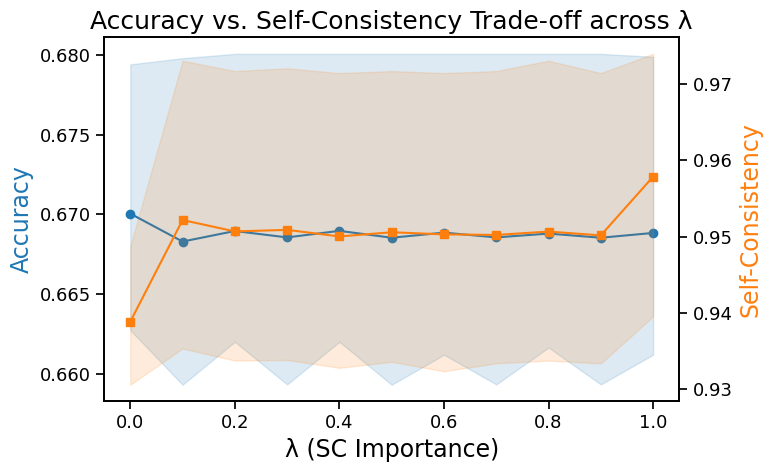

In [0]:
summary = combined_results_df.groupby("SC-Imp").agg(
    acc_mean=("Mean-Accuracy", "mean"),
    acc_q10=("Mean-Accuracy", lambda x: x.quantile(0.1)),
    acc_q90=("Mean-Accuracy", lambda x: x.quantile(0.9)),
    sc_mean=("Mean-SC", "mean"),
    sc_q10=("Mean-SC", lambda x: x.quantile(0.1)),
    sc_q90=("Mean-SC", lambda x: x.quantile(0.9)),
).reset_index()

fig, ax1 = plt.subplots(figsize=(8, 5))

ax1.plot(summary["SC-Imp"], summary["acc_mean"], marker="o", color="tab:blue", label="Mean Accuracy")
ax1.fill_between(summary["SC-Imp"], summary["acc_q10"], summary["acc_q90"], color="tab:blue", alpha=0.15)
ax1.set_xlabel("λ (SC Importance)", fontsize=17)
ax1.set_ylabel("Accuracy", color="tab:blue", fontsize=17)
ax1.tick_params(axis="both", labelsize=13)

ax2 = ax1.twinx()
ax2.plot(summary["SC-Imp"], summary["sc_mean"], marker="s", color="tab:orange", label="Mean Self-Consistency")
ax2.fill_between(summary["SC-Imp"], summary["sc_q10"], summary["sc_q90"], color="tab:orange", alpha=0.15)
ax2.set_ylabel("Self-Consistency", color="tab:orange", fontsize=17)
ax2.tick_params(axis="y", labelsize=13)

plt.title("Accuracy vs. Self-Consistency Trade-off across λ", fontsize=18)
fig.tight_layout()
fig.savefig("compas_sc_vs_accuracy_forlam.png", dpi=300, bbox_inches="tight")
plt.show()

In [0]:
pd.set_option("display.float_format", lambda x: f"{x:.4f}")
print(summary)

    SC-Imp  acc_mean  acc_q10  acc_q90  sc_mean  sc_q10  sc_q90
0   0.0000    0.6701   0.6628   0.6794   0.9389  0.9306  0.9487
1   0.1000    0.6683   0.6593   0.6798   0.9522  0.9354  0.9730
2   0.2000    0.6690   0.6620   0.6801   0.9507  0.9338  0.9716
3   0.3000    0.6686   0.6593   0.6801   0.9509  0.9339  0.9720
4   0.4000    0.6690   0.6620   0.6801   0.9500  0.9328  0.9714
5   0.5000    0.6685   0.6593   0.6801   0.9506  0.9336  0.9716
6   0.6000    0.6689   0.6612   0.6801   0.9503  0.9324  0.9714
7   0.7000    0.6686   0.6593   0.6801   0.9502  0.9334  0.9716
8   0.8000    0.6688   0.6617   0.6801   0.9507  0.9338  0.9730
9   0.9000    0.6685   0.6593   0.6801   0.9502  0.9334  0.9714
10  1.0000    0.6688   0.6612   0.6799   0.9578  0.9396  0.9739


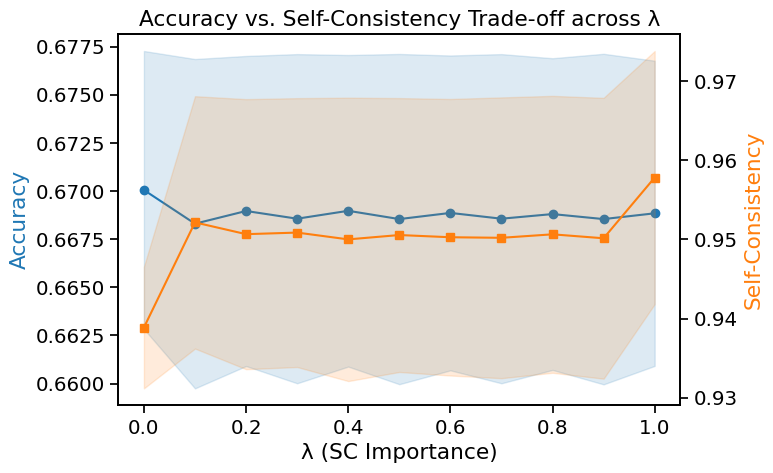

In [0]:
summary = combined_results_df.groupby("SC-Imp").agg(
    acc_mean=("Mean-Accuracy", "mean"),
    acc_std=("Mean-Accuracy", "std"),
    sc_mean=("Mean-SC", "mean"),
    sc_std=("Mean-SC", "std"),
).reset_index()

fig, ax1 = plt.subplots(figsize=(8, 5))

ax1.plot(summary["SC-Imp"], summary["acc_mean"], marker="o", color="tab:blue", label="Mean Accuracy")
ax1.fill_between(summary["SC-Imp"], summary["acc_mean"] - summary["acc_std"], summary["acc_mean"] + summary["acc_std"], color="tab:blue", alpha=0.15)
ax1.set_xlabel("λ (SC Importance)")
ax1.set_ylabel("Accuracy", color="tab:blue")

ax2 = ax1.twinx()
ax2.plot(summary["SC-Imp"], summary["sc_mean"], marker="s", color="tab:orange", label="Mean Self-Consistency")
ax2.fill_between(summary["SC-Imp"], summary["sc_mean"] - summary["sc_std"], summary["sc_mean"] + summary["sc_std"], color="tab:orange", alpha=0.15)
ax2.set_ylabel("Self-Consistency", color="tab:orange")

plt.title("Accuracy vs. Self-Consistency Trade-off across λ")
fig.tight_layout()
fig.savefig("compas_sc_vs_accuracy_forlam.png", dpi=300, bbox_inches="tight")
plt.show()

In [0]:
weight_cols = [f"{v} (w)" for v in models_set.values()]  # ["LR (w)", "DT (w)", "RF (w)", "GB (w)"]

weight_summary = combined_results_df.groupby("SC-Imp")[weight_cols].mean().reset_index()

In [0]:
weight_summary

,SC-Imp,LR (w),DT (w),RF (w),GB (w)
0,0.0,0.61831,0.00000,0.02078,0.36090
1,0.1,0.93834,0.00962,0.01018,0.04187
2,0.2,0.91421,0.00729,0.00710,0.07138
3,0.3,0.90103,0.00773,0.01121,0.08001
4,0.4,0.89649,0.00981,0.00903,0.08465
5,0.5,0.88369,0.00857,0.00961,0.09811
6,0.6,0.89477,0.00392,0.01207,0.08922
7,0.7,0.88561,0.01251,0.01207,0.08979
8,0.8,0.91523,0.01168,0.01139,0.06170
9,0.9,0.88487,0.01157,0.01251,0.09102


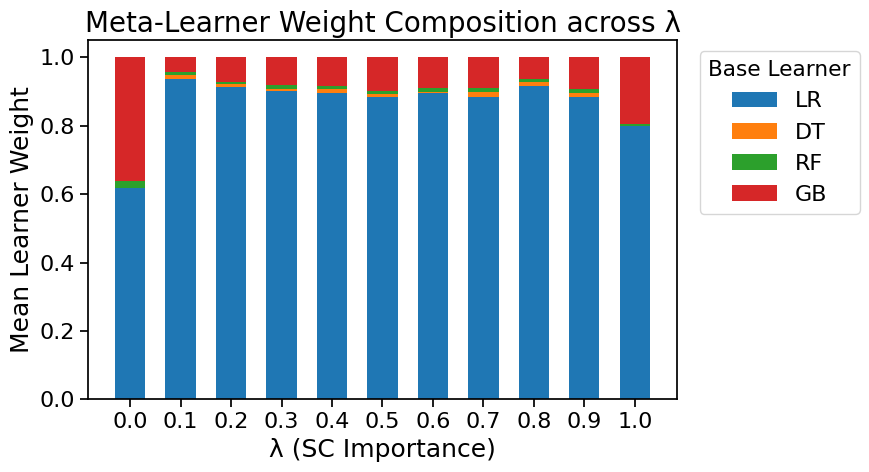

In [0]:
fig, ax = plt.subplots(figsize=(9, 5))

bottom = np.zeros(len(weight_summary))
colors = {"LR (w)": "tab:blue", "DT (w)": "tab:orange", "RF (w)": "tab:green", "GB (w)": "tab:red"}

for col in weight_cols:
    ax.bar(weight_summary["SC-Imp"].astype(str), weight_summary[col], bottom=bottom, label=col.replace(" (w)", ""), color=colors[col], width=0.6)
    bottom += weight_summary[col].values

ax.set_xlabel("λ (SC Importance)")
ax.set_ylabel("Mean Learner Weight")
ax.set_title("Meta-Learner Weight Composition across λ")
ax.legend(title="Base Learner", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
fig.savefig("compas_meta_learner_weights_for_lam.png", dpi=300, bbox_inches="tight")
plt.show()

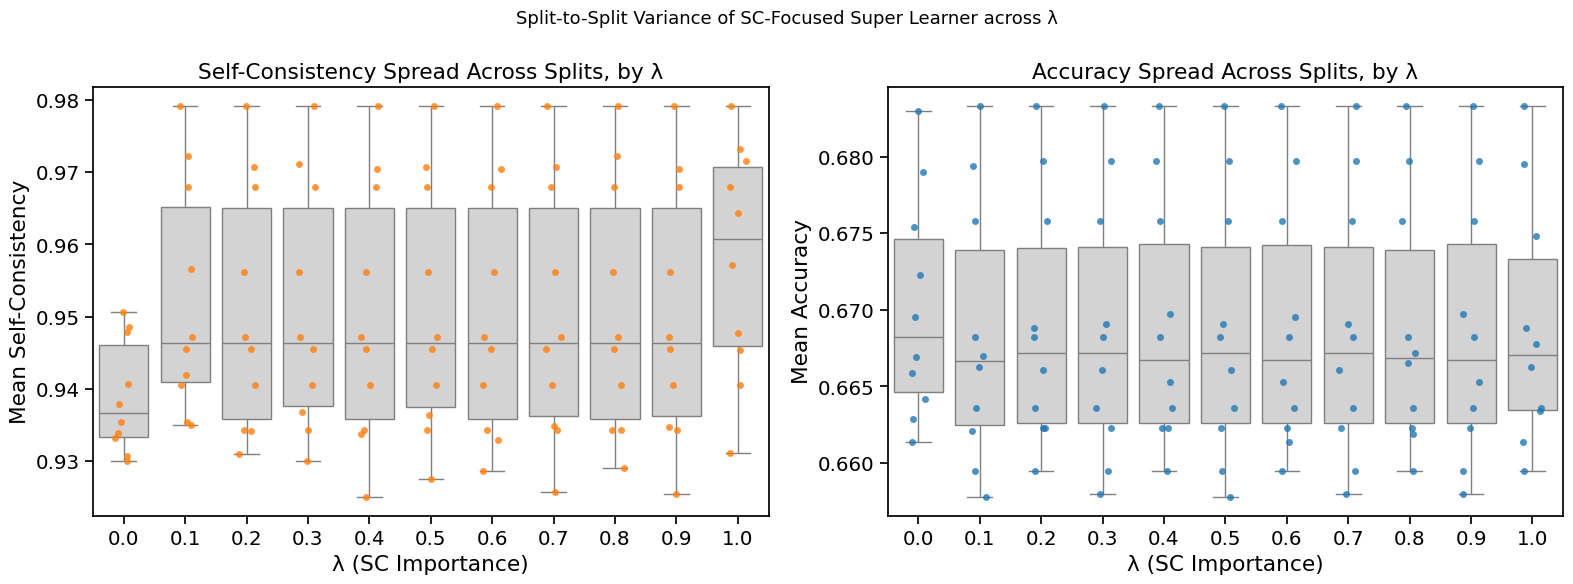

In [0]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Mean-SC across splits, faceted by lambda ---
sns.boxplot(data=combined_results_df, x="SC-Imp", y="Mean-SC", ax=axes[0], color="lightgray", fliersize=0)
sns.stripplot(data=combined_results_df, x="SC-Imp", y="Mean-SC", ax=axes[0], color="tab:orange", size=5, jitter=0.15, alpha=0.8)
axes[0].set_xlabel("λ (SC Importance)")
axes[0].set_ylabel("Mean Self-Consistency")
axes[0].set_title("Self-Consistency Spread Across Splits, by λ")

# --- Mean-Accuracy across splits, faceted by lambda ---
sns.boxplot(data=combined_results_df, x="SC-Imp", y="Mean-Accuracy", ax=axes[1], color="lightgray", fliersize=0)
sns.stripplot(data=combined_results_df, x="SC-Imp", y="Mean-Accuracy", ax=axes[1], color="tab:blue", size=5, jitter=0.15, alpha=0.8)
axes[1].set_xlabel("λ (SC Importance)")
axes[1].set_ylabel("Mean Accuracy")
axes[1].set_title("Accuracy Spread Across Splits, by λ")

fig.suptitle("Split-to-Split Variance of SC-Focused Super Learner across λ", fontsize=13)
fig.tight_layout()
fig.savefig("compas_sc_accuracy_boxplot_for_lam.png", dpi=300, bbox_inches="tight")
plt.show()

In [0]:
sc_cols = ["SC (LR)", "SC (DT)", "SC (RF)", "SC (GB)"]
acc_cols = ["Acc (LR)", "Acc (DT)", "Acc (RF)", "Acc (GB)"]

# Individual learners: average across splits (same for every lambda, so just take lambda=0 rows)
indiv = combined_results_df[combined_results_df["SC-Imp"] == 0][sc_cols + acc_cols].mean()

# Meta-learner: average across splits, at each lambda you want to show
meta = combined_results_df.groupby("SC-Imp")[["Mean-SC", "Mean-Accuracy"]].mean().reset_index()

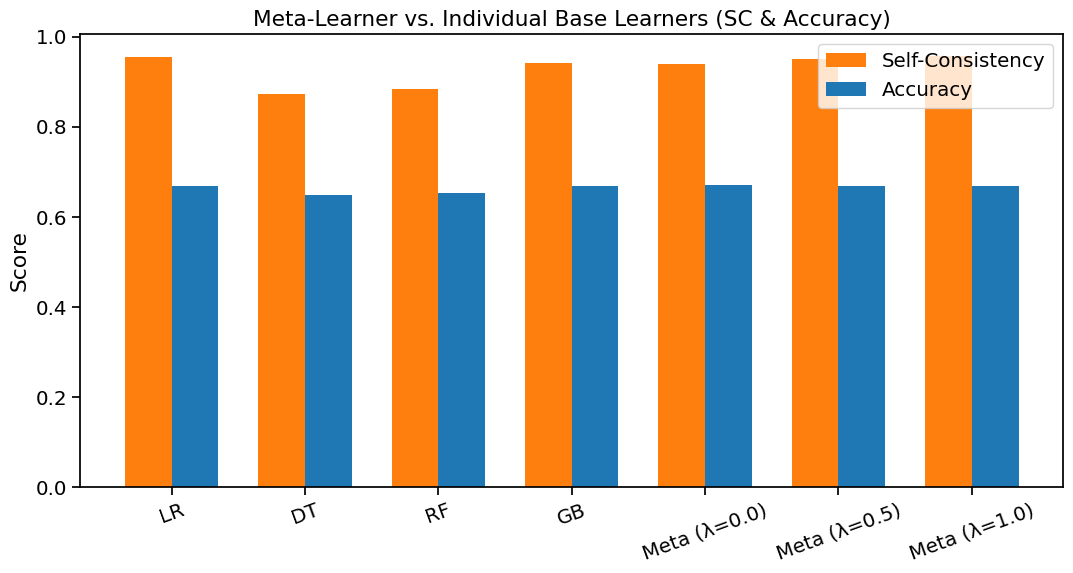

In [0]:
learners = ["LR", "DT", "RF", "GB"]
meta_lambdas = [0.0, 0.5, 1.0]

labels = learners + [f"Meta (λ={l})" for l in meta_lambdas]
sc_values = [indiv[f"SC ({l})"] for l in learners] + [meta.loc[meta["SC-Imp"] == l, "Mean-SC"].values[0] for l in meta_lambdas]
acc_values = [indiv[f"Acc ({l})"] for l in learners] + [meta.loc[meta["SC-Imp"] == l, "Mean-Accuracy"].values[0] for l in meta_lambdas]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))
ax.bar(x - width/2, sc_values, width, label="Self-Consistency", color="tab:orange")
ax.bar(x + width/2, acc_values, width, label="Accuracy", color="tab:blue")

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=20)
ax.set_ylabel("Score")
ax.set_title("Meta-Learner vs. Individual Base Learners (SC & Accuracy)")
ax.legend()
fig.tight_layout()
fig.savefig("compas_super_learner_vs_individual_learner_for_lam.png", dpi=300, bbox_inches="tight")
plt.show()

In [0]:
import time
 
minute = 20
for i in range(minute):    
    print(f"Spark heartbeat {i+1}")
    time.sleep(60)
    i = i+1

Spark heartbeat 1
Spark heartbeat 2
Spark heartbeat 3
Spark heartbeat 4
Spark heartbeat 5
Spark heartbeat 6
Spark heartbeat 7
Spark heartbeat 8
Spark heartbeat 9
Spark heartbeat 10
Spark heartbeat 11


### Meta vs Individual SC for Classical Super Learner and SC-Focused Super Learner

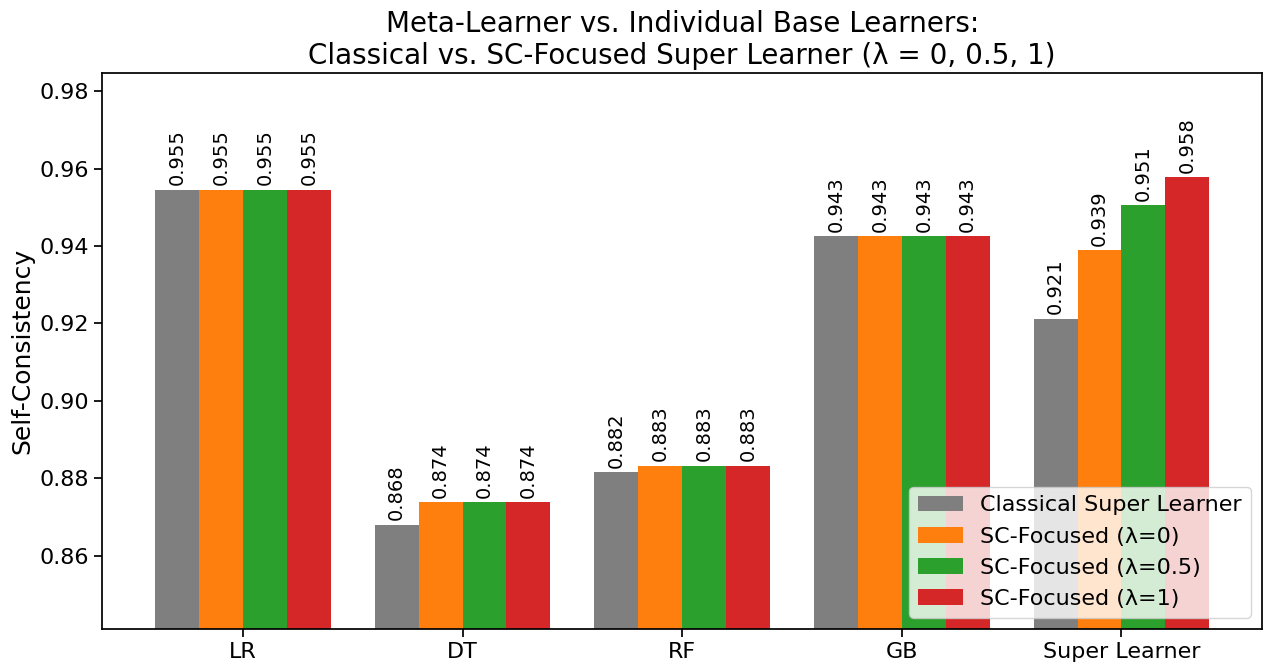

In [0]:
plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 20,
    "axes.labelsize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16,
})
# Step 1 — Classical
classical_dedup = combined_classical_df.groupby("outer_split").first().reset_index()
classical_sc = {
    "Super Learner": classical_dedup["Meta Learner SC"].mean(),
    "LR": classical_dedup["Logistic Regression SC"].mean(),
    "DT": classical_dedup["Decision Tree SC"].mean(),
    "RF": classical_dedup["Random Forest SC"].mean(),
    "GB": classical_dedup["Gradient Boosting SC"].mean(),
}

# Step 2 — SC-Focused, one dict per lambda
def get_sc_focused_values(lam):
    subset = combined_results_df[combined_results_df["SC-Imp"] == lam]
    return {
        "Super Learner": subset["Mean-SC"].mean(),
        "LR": subset["SC (LR)"].mean(),
        "DT": subset["SC (DT)"].mean(),
        "RF": subset["SC (RF)"].mean(),
        "GB": subset["SC (GB)"].mean(),
    }

sc_focused_0 = get_sc_focused_values(0)
sc_focused_05 = get_sc_focused_values(0.5)
sc_focused_1 = get_sc_focused_values(1)

# Step 3 — Grouped bar chart, 4 bars per learner
learners = ["LR", "DT", "RF", "GB", "Super Learner"]
series = {
    "Classical Super Learner": [classical_sc[l] for l in learners],
    "SC-Focused (λ=0)": [sc_focused_0[l] for l in learners],
    "SC-Focused (λ=0.5)": [sc_focused_05[l] for l in learners],
    "SC-Focused (λ=1)": [sc_focused_1[l] for l in learners],
}
colors = ["tab:gray", "tab:orange", "tab:green", "tab:red"]

x = np.arange(len(learners))
n_series = len(series)
width = 0.8 / n_series  # total group width 0.8, split across bars

fig, ax = plt.subplots(figsize=(13, 7))
all_values = []
for i, (label, values) in enumerate(series.items()):
    offset = (i - (n_series - 1) / 2) * width
    bars = ax.bar(x + offset, values, width, label=label, color=colors[i])
    ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=14, rotation=90)
    all_values.extend(values)

# Scale y-axis to the data range instead of starting at 0
y_min, y_max = min(all_values), max(all_values)
padding = (y_max - y_min) * 0.3 if y_max > y_min else 0.02
ax.set_ylim(max(0, y_min - padding), min(1.05, y_max + padding))

ax.set_xticks(x)
ax.set_xticklabels(learners)
ax.set_ylabel("Self-Consistency")
ax.set_title(
    "Meta-Learner vs. Individual Base Learners:\n"
    "Classical vs. SC-Focused Super Learner (λ = 0, 0.5, 1)"
)
ax.legend(loc="lower right")
fig.tight_layout()

fig.savefig("compas_classical_vs_sc_focused_learners_sc_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

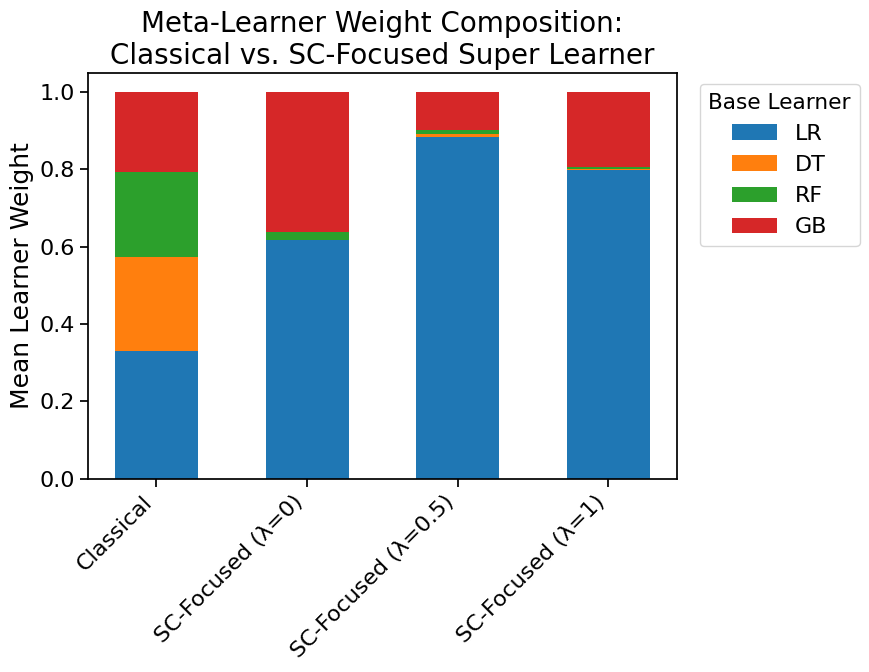

In [0]:
models_types = ["Logistic Regression", "Random Forest", "Decision Tree", "Gradient Boosting"]
models_set = {"Logistic Regression" : "LR", "Decision Tree" : "DT", "Random Forest" : "RF", "Gradient Boosting" : "GB"}

name_to_abbrev = models_set

classical_weight_means = combined_classical_df[[f"{m} (w)" for m in name_to_abbrev.keys()]].mean()
classical_weight_means.index = [name_to_abbrev[c.replace(" (w)", "")] for c in classical_weight_means.index]

sc_focused_weight_cols = [f"{v} (w)" for v in models_set.values()]

def get_sc_focused_weights(lam):
    subset = combined_results_df[combined_results_df["SC-Imp"] == lam]
    means = subset[sc_focused_weight_cols].mean()
    means.index = [c.replace(" (w)", "") for c in means.index]
    return means

sc_focused_0 = get_sc_focused_weights(0)
sc_focused_05 = get_sc_focused_weights(0.5)
sc_focused_1 = get_sc_focused_weights(1)

weight_summary = pd.DataFrame({
    "Classical": classical_weight_means,
    "SC-Focused (λ=0)": sc_focused_0,
    "SC-Focused (λ=0.5)": sc_focused_05,
    "SC-Focused (λ=1)": sc_focused_1,
}).T

learners = weight_summary.columns.tolist()
colors = {learners[0]: "tab:blue", learners[1]: "tab:orange", learners[2]: "tab:green", learners[3]: "tab:red"}

fig, ax = plt.subplots(figsize=(9, 7))

bottom = np.zeros(len(weight_summary))
for learner in learners:
    values = weight_summary[learner].values
    ax.bar(weight_summary.index, values, bottom=bottom, label=learner, color=colors[learner], width=0.55)
    bottom += values

ax.set_ylabel("Mean Learner Weight")
ax.set_title("Meta-Learner Weight Composition:\nClassical vs. SC-Focused Super Learner")
ax.legend(title="Base Learner", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
fig.tight_layout()

fig.savefig("compas_classical_vs_sc_focused_weight_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [0]:
# Classical: accuracy columns are per-row (not pooled/broadcast), so average across all rows directly
classical_acc = {
    "LR": combined_classical_df["Logistic Regression accuracy"].mean(),
    "DT": combined_classical_df["Decision Tree accuracy"].mean(),
    "RF": combined_classical_df["Random Forest accuracy"].mean(),
    "GB": combined_classical_df["Gradient Boosting accuracy"].mean(),
    "Meta": combined_classical_df["Meta Model accuracy"].mean(),
}

# SC-Focused: average across the 10 splits, at each lambda
def get_sc_focused_acc(lam):
    subset = combined_results_df[combined_results_df["SC-Imp"] == lam]
    return {
        "LR": subset["Acc (LR)"].mean(),
        "DT": subset["Acc (DT)"].mean(),
        "RF": subset["Acc (RF)"].mean(),
        "GB": subset["Acc (GB)"].mean(),
        "Meta": subset["Mean-Accuracy"].mean(),
    }

sc_focused_acc_0 = get_sc_focused_acc(0)
sc_focused_acc_05 = get_sc_focused_acc(0.5)
sc_focused_acc_1 = get_sc_focused_acc(1)

accuracy_table = pd.DataFrame({
    "Classical": classical_acc,
    "SC-Focused (λ=0)": sc_focused_acc_0,
    "SC-Focused (λ=0.5)": sc_focused_acc_05,
    "SC-Focused (λ=1)": sc_focused_acc_1,
}).round(4)

accuracy_table = accuracy_table.loc[["LR", "DT", "RF", "GB", "Meta"]]  # fix row order

display(accuracy_table)

Classical,SC-Focused (λ=0),SC-Focused (λ=0.5),SC-Focused (λ=1)
0.6691,0.6691,0.6691,0.6691
0.6437,0.6492,0.6492,0.6492
0.6516,0.6522,0.6522,0.6522
0.6687,0.6687,0.6687,0.6687
0.6655,0.67,0.6685,0.6688


In [0]:
accuracy_table = pd.DataFrame({
    "Classical": classical_acc,
    "SC-Focused (λ=0)": sc_focused_acc_0,
    "SC-Focused (λ=0.5)": sc_focused_acc_05,
    "SC-Focused (λ=1)": sc_focused_acc_1,
}).round(4)

accuracy_table = accuracy_table.loc[["LR", "DT", "RF", "GB", "Meta"]]
accuracy_table.index.name = "Learner"
accuracy_table = accuracy_table.reset_index()  # turns the index into a normal "Learner" column

display(accuracy_table)

Learner,Classical,SC-Focused (λ=0),SC-Focused (λ=0.5),SC-Focused (λ=1)
LR,0.6691,0.6691,0.6691,0.6691
DT,0.6437,0.6492,0.6492,0.6492
RF,0.6516,0.6522,0.6522,0.6522
GB,0.6687,0.6687,0.6687,0.6687
Meta,0.6655,0.67,0.6685,0.6688
